# Physics-Informed Neural Network (PINN)

Section created based on the class material from [1] Seman (2025).

A Physics-Informed Neural Network (PINN) is a neural network that incorporates the underlying physical laws directly into the training process through a loss function. It approximates the solution of a physical system using the partial differential equations (PDEs) or ordinary differential equations (ODEs) to compute a part of the loss function.

## Loss function
The total loss function is given by:

$\mathcal{L}_{total} = \lambda_r \mathcal{L}_{PDE} + \lambda_b \mathcal{L}_{boundary} + \lambda_i \mathcal{L}_{initial} + \lambda_d \mathcal{L}_{data}$.

The loss surface is non-convex, ill-condiotioned, and highly sensitive due to the nature of neural networks (NNs), the nonlinear PDEs, and one loss term dominating the others.

### PDE Residual Loss

$\mathcal{L}_{PDE} = \frac{1}{N_r} \sum_{i=1}^{N_r} | \mathcal{F}[u_{\theta}(x_i, t_i)] |^2$

- $N_r$: number of collocation points $\{ (x_i, t_i) \}^{N_r}_{i=1}$ in the domain (for enforcing the PDE),
- $u_{\theta}(\boldsymbol{x},t)$: neural network that replaces the unknown function $u(\boldsymbol{x},t)$,
- $\mathcal{F}[u_{\theta}(x_i, t_i)]$: general PDE to solve.

### Boundary and Initial Condition Losses

The boundary loss enforecs the boundary conditions:

$\mathcal{L}_{boundary} = \frac{1}{N_b} \sum_{j=1}^{N_b} | u_{\theta}(x_j^{\partial\Omega}, t_j) - g_b(x_j^{\partial \Omega}, t_j) |^2$

The initial condition loss ensures proper initialization:

$\mathcal{L}_{initial} = \frac{1}{N_i} \sum_{k=1}{N_i} | u_{\theta}(x_k, 0) - u_0(x_k) |^2$

### Data Loss
If data is available,

$\mathcal{data} = \frac{1}{N_d} \sum_{l=1}^{N_d} | u_{\theta}(x_l, t_l) - u(x_l, t_l) |^2$.

### Loss Balancing
The weights $\{ \lambda_r, \lambda_b, \lambda_i, \lambda_d \}$ are important so that each term of the loss becomes balanced and does not dominate the problem. They can be tuned manually, normalized by gradient magnitudes or scaled by relative loss values.

## Strategies for a better training
- Monitor each loss individually to easily identify problems. Use adaptive weight scheduling, normalization, gradient clipping;
- Use adaptive collocation strategies to put new training points across the domain in the regions that are more difficult and use a better space-filling like Latin Hypercube Sampling (LHS) for the initial sampling plan. Carefully initialize the weights (e.g., Xavier/Glorot);
- Curriculum Learning:
    - PDE order schedule;
    - Collocation point schedule;
    - Temporal refinement; and
    - Parameter schedule;
- Transform inputs if necessary (e.g., Fourier transform);
- Select activation functions suitable to your problem;
- Adam optimizer for initial exploration (80% of training) and L-BFGS for final convergence;
- Multiple training runs with different initializations;
- Increase network capacity for complex problems;
- Validate on analytical solutions when available;
- Add Gradient information (Gradient-enhanced Physics-Informed Neural Networks - gPINNs); etc.

## Best Practices
### Network architecture
- Hidden layers: around 3-8 layers;
- Neurons per layer: 20-100;
- Activation functions: Tanh, Sine, or Swish; and
- Output layer: No activation for regression problems.

### Training strategies
- Optimizer: Adam (80% of training), L-BFGS for more accuracy;
- Learning rate: $10^{-3}$. Decay if needed;
- Loss balancing: Adaptive weights or manual tuning; and
- Training points: More physics points than boundary points usually.

# Problem: Euler-Bernoulli Beam with uniformly distributed load and elastic support

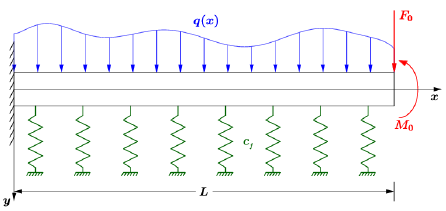

Source: *[2] Lopez (2025)*.

The PDE of the problem is:

$EIv^{IV}(x) + c_f v(x) - q(x) = 0$,

where:
- $v(x)$ is the transverse displacement of the beam,
- $E$ is the Young's modulus,
- $I$ is the moment of inertia,
- $c_f$ is the elastic stiffness of the spring,
- $q(x)$ is the distributed load, and
- $L$ is the length of the beam.

The boundary conditions are:

- $v(0) = 0$,
- $v'(0) = 0$,
- $EIv'''(L) = -F_0$, and
- $EIv''(L) = -M_0$.

Let's consider the following values:

Rectangular cross section $0.20$ m $\times 0.60$ m, length $L = 8$ m, Young's modulus $E = 200$ GPa, uniform load $q = 5$ kN/m, $F_0 = 2$ kN e $M_0 = 4$ kNm, elastic stiffness of the spring base $c_f = 4 \times 10^8$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, simplify, Eq, solve, Derivative, dsolve, Function
from sympy import lambdify
from sympy import trigsimp, re

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16

## Exact solution

In [2]:
def get_analytical_solution(x_analytical, L_in, E_in, I_in, F0_in, M0_in, cf_in, q_in):
    # Declaração simbólica
    E, I, L, Fo, Mo, cf, q = symbols('E I L Fo Mo cf q')
    x = symbols('x', real=True)
    v = Function('v')

    # EDO simbolicamente
    edo = Eq(E*I*Derivative(v(x), x, 4) + cf*v(x), q)

    # Resolve simbolicamente
    sol_geral = dsolve(edo, v(x))
    v_gen = sol_geral.rhs

    v1 = v_gen.diff(x, 1)
    v2 = v_gen.diff(x, 2)
    v3 = v_gen.diff(x, 3)

    conds = [
        Eq(v_gen.subs(x, 0), 0),
        Eq(v1.subs(x, 0), 0),
        Eq(v2.subs(x, L), -Mo / (E * I)),
        Eq(v3.subs(x, L), -Fo / (E * I)),
    ]

    # Descobre as constantes C1, C2...
    constantes = list(v_gen.free_symbols - {x, E, I, L, Fo, Mo, cf, q})
    sol_consts = solve(conds, constantes)

    # Substitui as constantes na solução geral
    v_final = simplify(v_gen.subs(sol_consts))

    # Valores numéricos
    valores = {
        E: E_in,
        cf: cf_in,
        L: L_in,
        I: I_in,
        q: q_in,
        Fo: F0_in,
        Mo: M0_in,
    }

    v_final_n = (v_final.subs(valores))
    v_final_nu = trigsimp(v_final_n)
    v_final_num = re(v_final_nu)

    # Transformar em função para plotar
    u_func = lambdify(x, v_final_num, modules='numpy')
    y_vals = u_func(x_analytical)

    return y_vals

In [3]:
def get_analytical_solution_no_cf(x_analytical, L_in, E_in, I_in, F0_in, M0_in, q_in):
    # Declaração simbólica
    E, I, L, Fo, Mo, q = symbols('E I L Fo Mo q')
    x = symbols('x', real=True)
    v = Function('v')

    # EDO simbolicamente
    edo = Eq(E*I*Derivative(v(x), x, 4), q)

    # Resolve simbolicamente
    sol_geral = dsolve(edo, v(x))
    v_gen = sol_geral.rhs

    v1 = v_gen.diff(x, 1)
    v2 = v_gen.diff(x, 2)
    v3 = v_gen.diff(x, 3)

    conds = [
        Eq(v_gen.subs(x, 0), 0),
        Eq(v1.subs(x, 0), 0),
        Eq(v2.subs(x, L), -Mo / (E * I)),
        Eq(v3.subs(x, L), -Fo / (E * I)),
    ]

    # Descobre as constantes C1, C2...
    constantes = list(v_gen.free_symbols - {x, E, I, L, Fo, Mo, q})
    sol_consts = solve(conds, constantes)

    # Substitui as constantes na solução geral
    v_final = simplify(v_gen.subs(sol_consts))

    # Valores numéricos
    valores = {
        E: E_in,
        L: L_in,
        I: I_in,
        q: q_in,
        Fo: F0_in,
        Mo: M0_in,
    }

    v_final_n = (v_final.subs(valores))
    v_final_nu = trigsimp(v_final_n)
    v_final_num = re(v_final_nu)

    # Transformar em função para plotar
    u_func = lambdify(x, v_final_num, modules='numpy')
    y_vals = u_func(x_analytical)

    return y_vals

## PINN solution

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, LBFGS
import torch.autograd as autograd
from scipy.stats import qmc
import time

In [5]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network for Euler-Bernoulli Beam on Elastic Foundation
    """
    def __init__(self, layers, activation=torch.tanh):
        super(PINN, self).__init__()
        self.activation = activation
        self.linears = nn.ModuleList()
        # Build network layers
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        # Initialize weights using Xavier initialization
        self.init_weights()

    def init_weights(self):
        for m in self.linears:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        if x.dim() == 1:
            x = x.view(-1, 1)

        for i, layer in enumerate(self.linears[:-1]):
            x = self.activation(layer(x))
        x = self.linears[-1](x)  # No activation on output layer
        return x
    
    def boundary_losses(self, L, E, I, F0, M0, device='cpu'):
        # v(0) = 0
        # v'(0) = 0
        # EIv'''(L) = -F_0
        # EIv''(L) = -M_0
        
        # Define boundary points and move them to the correct device
        x_0 = torch.tensor([0.0], requires_grad=True, device=device).view(-1, 1)
        x_L = torch.tensor([L], requires_grad=True, device=device).view(-1, 1)
        
        # Boundary condition 1: v(0) = 0
        v_0 = self.forward(x_0)
        loss_bc1 = torch.mean(v_0**2)
        
        # Boundary condition 2: v'(0) = 0
        v_x_0 = torch.autograd.grad(
            outputs=v_0, 
            inputs=x_0, 
            grad_outputs=torch.ones_like(v_0), 
            create_graph=True
        )[0]
        loss_bc2 = torch.mean(v_x_0**2)
        
        # Boundary condition 3: EIv'''(L) = -F_0
        v_L = self.forward(x_L)

        ## First derivative at L: v'(L)
        v_x_L = torch.autograd.grad(
            outputs=v_L,
            inputs=x_L,
            grad_outputs=torch.ones_like(v_L),
            create_graph=True
        )[0]

        ## Second derivative at L: v''(L)
        v_xx_L = torch.autograd.grad(
            outputs=v_x_L,
            inputs=x_L,
            grad_outputs=torch.ones_like(v_x_L),
            create_graph=True
        )[0]

        ## Third derivative at L: v'''(L)
        v_xxx_L = torch.autograd.grad(
            outputs=v_xx_L,
            inputs=x_L,
            grad_outputs=torch.ones_like(v_xx_L),
            create_graph=True
        )[0]
        
        shear_force_pred = E * I * v_xxx_L
        loss_bc3 = torch.mean((shear_force_pred + F0)**2)
        
        # Boundary condition 4: EIv''(L) = -M_0
        bending_moment_pred = E * I * v_xx_L
        loss_bc4 = torch.mean((bending_moment_pred + M0)**2)
        
        # Total boundary loss
        loss_boundary = (loss_bc1 + loss_bc2 + loss_bc3 + loss_bc4) / 4
        
        return loss_boundary / (E * I), loss_bc1, loss_bc2, loss_bc3, loss_bc4
    
    def compute_residual(self, x, E, I, cf, q):
        x.requires_grad_(True)
        v = self.forward(x)
        # Compute the derivatives
        v_x = autograd.grad(v, x,
                            torch.ones_like(v), create_graph=True)[0]
        v_xx = autograd.grad(v_x, x,
                             torch.ones_like(v_x), create_graph=True)[0]
        v_xxx = autograd.grad(v_xx, x,
                              torch.ones_like(v_xx), create_graph=True)[0]
        v_xxxx = autograd.grad(v_xxx, x,
                               torch.ones_like(v_xxx), create_graph=True)[0]
        
        return E * I * v_xxxx + cf * v - q

    def physics_loss(self, x, E, I, cf, q):
        """Computes the standard physics loss (mean squared residual)."""
        pde_residual = self.compute_residual(x, E, I, cf, q)
        loss_physics = torch.mean(pde_residual**2)
        return loss_physics / (E * I)
    
    def gradient_physics_loss(self, x, E, I, cf, q):
        """Computes the gPINN loss (mean squared gradient of the residual)."""
        pde_residual = self.compute_residual(x, E, I, cf, q)
        grad_residual = torch.autograd.grad(pde_residual, x, torch.ones_like(pde_residual), create_graph=True)[0]
        loss_grad_physics = torch.mean(grad_residual**2)
        # We scale this loss term as well for balance
        return loss_grad_physics / (E * I)

In [6]:
def save_checkpoint(model, filename="best_model.pth"):
    """Saves the model's state dictionary."""
    torch.save(model.state_dict(), filename)

def load_checkpoint(model, filename="best_model.pth", device="cpu"):
    """Loads the model's state dictionary."""
    print(f"Loading best model from {filename}...")
    model.load_state_dict(torch.load(filename, map_location=device))

Training with:
- Batching for saving memory
- Gradient clipping because loss oscillates and sometimes explodes
- L-BFGS because training takes too long even using GPU

In [7]:
def train_with_batching(model, optimizer, scheduler, epochs, x_physics, batch_size,
                        L, E, I, F0, M0, cf, q, lambda_bc, device, checkpoint_path):
    """
    Trains the PINN using mini-batches to save memory and improve training dynamics.

    :param model: The PINN model (an nn.Module).
    :param optimizer: The PyTorch optimizer (e.g., Adam).
    :param epochs: The total number of training epochs.
    :param x_physics: A tensor of all collocation points for the physics loss.
    :param batch_size: The number of collocation points in each mini-batch.
    :param L, E, I, F0, M0, cf, q: Physical parameters of the beam problem.
    :param lambda_bc: The weighting factor for the boundary loss.
    :param device: The device to run on ('cpu' or 'cuda').
    :return: A list containing the history of the total loss per epoch.
    """
    loss_history, phys_loss_hist, bound_loss_hist = [], [], []
    best_loss = float('inf')
    
    adam_epochs = int(epochs * 0.8)
    
    # Main training loop
    for epoch in range(adam_epochs):
        model.train()
        
        # Shuffle the collocation points at the beginning of each epoch
        shuffled_indices = torch.randperm(x_physics.size(0))
        x_physics_shuffled = x_physics[shuffled_indices]

        # Initialize accumulators for epoch-level loss reporting
        epoch_total_loss = 0.0
        epoch_phys_loss = 0.0
        epoch_bound_loss = 0.0
        
        n_batches = len(x_physics) // batch_size
        start_time = time.time()

        # Loop over mini-batches
        for i in range(n_batches):
            # 1. Get the mini-batch
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            x_batch = x_physics_shuffled[start_idx:end_idx]

            # 2. Zero the gradients
            optimizer.zero_grad()

            # 3. Calculate losses
            # Physics loss for the current batch of collocation points
            loss_p = model.physics_loss(x_batch, E, I, cf, q)
            
            # Boundary loss (calculated in every step to contribute to the gradient)
            loss_b, _, _, _, _ = model.boundary_losses(L, E, I, F0, M0, device)
            
            # Combine losses with the weighting factor
            total_loss = loss_p + lambda_bc * loss_b

            # 4. Backpropagate, clip, and update weights
            total_loss.backward(retain_graph=True)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # 5. Accumulate losses for logging
            epoch_total_loss += total_loss.item()
            epoch_phys_loss += loss_p.item()
            epoch_bound_loss += loss_b.item()

        scheduler.step()
        
        # Calculate average losses for the completed epoch
        avg_total_loss = epoch_total_loss / n_batches
        avg_phys_loss = epoch_phys_loss / n_batches
        avg_bound_loss = epoch_bound_loss / n_batches
        loss_history.append(avg_total_loss)
        phys_loss_hist.append(avg_phys_loss)
        bound_loss_hist.append(avg_bound_loss)
        
        # Checkpoint
        if avg_total_loss < best_loss:
            best_loss = avg_total_loss
            save_checkpoint(model, checkpoint_path)

        if (epoch + 1) % 1000 == 0:
            elapsed_time = time.time() - start_time
            print(f'Epoch {epoch+1}/{epochs} | '
                  f'Avg Total Loss: {avg_total_loss:.4e} | '
                  f'Avg Physics Loss: {avg_phys_loss:.4e} | '
                  f'Avg Boundary Loss: {avg_bound_loss*lambda_bc:.4e} | '
                  f'Time: {elapsed_time:.2f}s')
        
    print(f"\n--- Phase 2: L-BFGS Optimizer for final convergence ---")
    # Load the best model found during the Adam phase
    load_checkpoint(model, checkpoint_path, device)
    model.train()

    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=500, # A smaller number of iterations for fine-tuning
        max_eval=5000,
        tolerance_grad=1e-7,
        tolerance_change=1.0 * np.finfo(float).eps,
        history_size=100,
        line_search_fn="strong_wolfe"
    )

    final_loss_container = [0.0]
    final_loss_p = [0.0]
    final_loss_b = [0.0]
    def closure():
        optimizer_lbfgs.zero_grad()
        # Use the full dataset for the most accurate gradient
        loss_p = model.physics_loss(x_physics, E, I, cf, q)
        loss_b, _, _, _, _ = model.boundary_losses(L, E, I, F0, M0, device)
        loss = loss_p + lambda_bc * loss_b
        loss.backward()
        final_loss_container[0] = loss.item()
        final_loss_p[0] = loss_p.item()
        final_loss_b[0] = loss_b.item()
        return loss

    optimizer_lbfgs.step(closure)
    
    if final_loss_container[0] < best_loss:
        best_loss = final_loss_container[0]
        save_checkpoint(model, checkpoint_path)
    
    print(f"Final L-BFGS Loss: {final_loss_container[0]:.4e}")
    # Append the final loss to see the drop from L-BFGS
    loss_history.append(final_loss_container[0])
    phys_loss_hist.append(final_loss_p[0])
    bound_loss_hist.append(final_loss_b[0])
    
    return loss_history, phys_loss_hist, bound_loss_hist

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

L = 1.0
E = 200e9
b = 0.20
h = 0.60
I = (b * h**3) / 12
q = 5e3
cf = 0
F0 = 2e3
M0 = 4e3

Using device: cuda


In [9]:
x_test = torch.linspace(0, L, 500, device=device).view(-1, 1)

In [10]:
x_analytical = x_test.cpu().numpy().flatten()
# v_analytical = get_analytical_solution(x_analytical, L, E, I, F0, M0, cf, q)
v_analytical = get_analytical_solution_no_cf(x_analytical, L, E, I, F0, M0, q)

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1000/20000 | Avg Total Loss: 1.4650e+05 | Avg Physics Loss: 1.1545e+03 | Avg Boundary Loss: 1.4535e+05 | Time: 0.19s
Epoch 2000/20000 | Avg Total Loss: 3.1601e+04 | Avg Physics Loss: 1.3972e+02 | Avg Boundary Loss: 3.1462e+04 | Time: 0.18s
Epoch 3000/20000 | Avg Total Loss: 1.8819e+03 | Avg Physics Loss: 1.7551e+01 | Avg Boundary Loss: 1.8643e+03 | Time: 0.19s
Epoch 4000/20000 | Avg Total Loss: 1.0356e+03 | Avg Physics Loss: 7.7995e+00 | Avg Boundary Loss: 1.0278e+03 | Time: 0.18s
Epoch 5000/20000 | Avg Total Loss: 6.0856e+02 | Avg Physics Loss: 4.2613e+00 | Avg Boundary Loss: 6.0430e+02 | Time: 0.19s
Epoch 6000/20000 | Avg Total Loss: 3.7614e+02 | Avg Physics Loss: 1.3646e+00 | Avg Boundary Loss: 3.7478e+02 | Time: 0.18s
Epoch 7000/20000 | Avg Total Loss: 7.3079e+02 | Avg Physics Loss: 1.9687e+00 | Avg Boundary Loss: 7.2882e+02 | Time: 0.18s
Epoch 8000/20000 | Avg Total Loss: 3.5924e+02 | Avg Physics Loss: 8.8934e-01 | Avg Boundary Loss: 3.5835e+02 | Time: 0.18s
Epoch 9000/20000

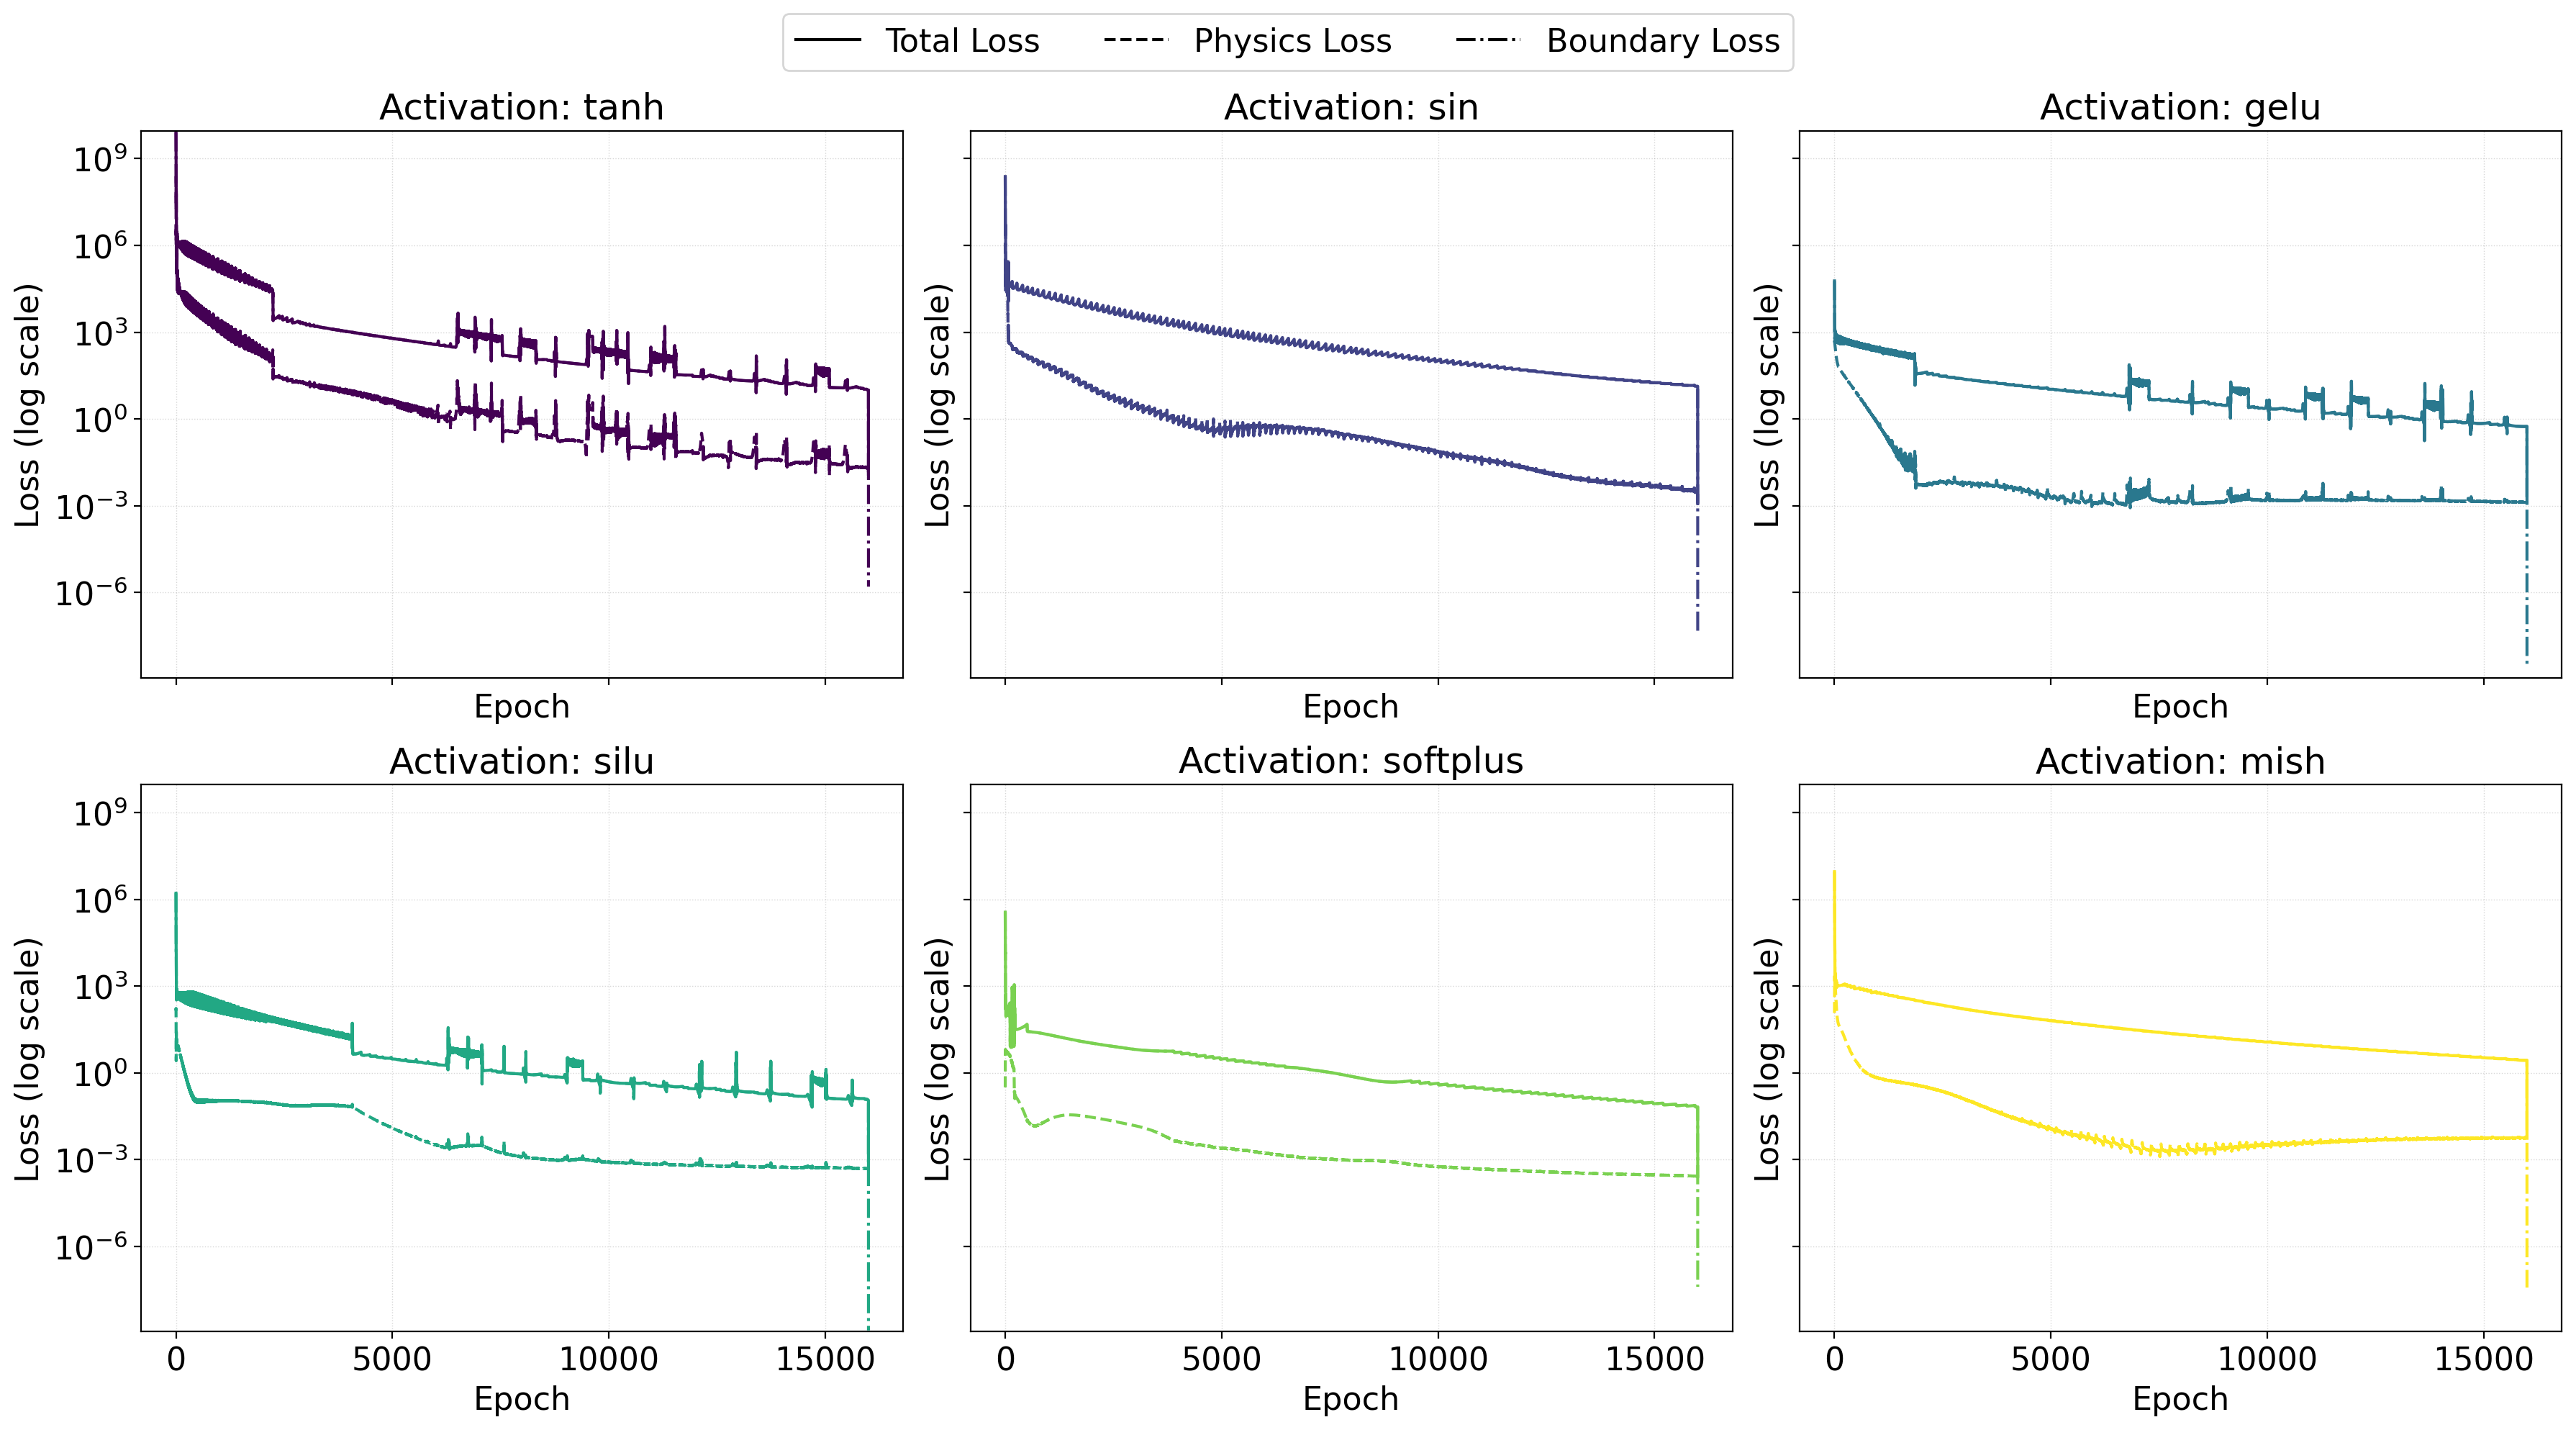

In [11]:
# PINN architecture
layers = [1, 64, 64, 64, 64, 64, 1]
activation = F.softplus

# activations = [torch.tanh, torch.sin, F.gelu, F.silu]
activations = [torch.tanh, torch.sin, F.gelu, F.silu, F.softplus, F.mish]

# Training parameters
learning_rate = 1e-4
epochs = 20000
batch_size = 500
n_physics_points = 2000
lambda_bc = 1000.0

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(activations)))
all_losses = [] # To store all loss values for uniform y-limits
v_predictions = []
labels = []
for k in range(len(activations)):
    # Instantiate model and optimizer
    pinn = PINN(layers, activations[k]).to(device)
    optimizer = torch.optim.Adam(pinn.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9999)

    # Create collocation points for the physics loss (randomly sampled)
    x_physics = torch.rand(n_physics_points, 1, device=device) * L
    x_physics.requires_grad = True

    # For saving the best model
    checkpoint_filename = "best_PINN" + activations[k].__name__ + ".pth"

    # Run training
    loss_hist, phys_loss_hist, bound_loss_hist = train_with_batching(
        pinn, optimizer, scheduler, epochs, x_physics, batch_size, L, E, I, F0, M0, cf, q, lambda_bc, device, checkpoint_filename
    )
    
    load_checkpoint(pinn, checkpoint_filename, device)

    pinn.eval()

    with torch.no_grad():
        v_pred = pinn(x_test)
    
    v_predictions.append(v_pred)
    labels.append(f"PINN w/ {activations[k].__name__}")
    
    # Plotting
    ax = axes.flat[k]
    ax.plot(loss_hist, color=colors[k], linestyle='-', label='Total Loss')
    ax.plot(phys_loss_hist, color=colors[k], linestyle='--', label='Physics Loss')
    ax.plot(np.array(bound_loss_hist) * lambda_bc, color=colors[k], linestyle='-.', label=f'Boundary Loss (x{lambda_bc:.0f})')
    
    ax.set_yscale('log')
    ax.set_title(f"Activation: {activations[k].__name__}")
    ax.grid(True, which="both", ls=":")
    
    # Store losses to calculate global y-limits later
    all_losses.extend(loss_hist)
    all_losses.extend(phys_loss_hist)
    all_losses.extend(np.array(bound_loss_hist) * lambda_bc)

# Final plotting configuration
min_loss = np.nanmin(all_losses)
max_loss = np.nanmax(all_losses)
for ax in axes.flat:
    ax.set_ylim(min_loss * 0.9, max_loss * 1.1)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")

lines = [plt.Line2D([0], [0], color='black', linestyle='-'),
         plt.Line2D([0], [0], color='black', linestyle='--'),
         plt.Line2D([0], [0], color='black', linestyle='-.')]
labels = ['Total Loss', 'Physics Loss', 'Boundary Loss']
fig.legend(lines, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.0))

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for the suptitle
plt.show()

In [17]:
def plot_results(x_test, v_analytical, v_predictions, labels):
    # Plotting results
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax2) = plt.subplots(1, 1, figsize=(18, 6))

    ax2.plot(x_test.cpu().numpy(), v_analytical * 1000, 'k-', label='Analytical Solution', linewidth=2.5)
    
    colors = ['r', 'b', 'g', 'y', 'm', 'c']
    for i in range(len(v_predictions)):
        ax2.plot(x_test.cpu().numpy(), v_predictions[i].cpu().numpy() * 1000, colors[i]+'--', label=labels[i], linewidth=2.3-i*0.2)

    ax2.set_title('PINNs Solutions vs. Analytical Solution')
    ax2.set_xlabel('Position along beam, x (m)')
    ax2.set_ylabel('Deflection, v(x) (mm)')
    ax2.legend()
    ax2.invert_yaxis()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

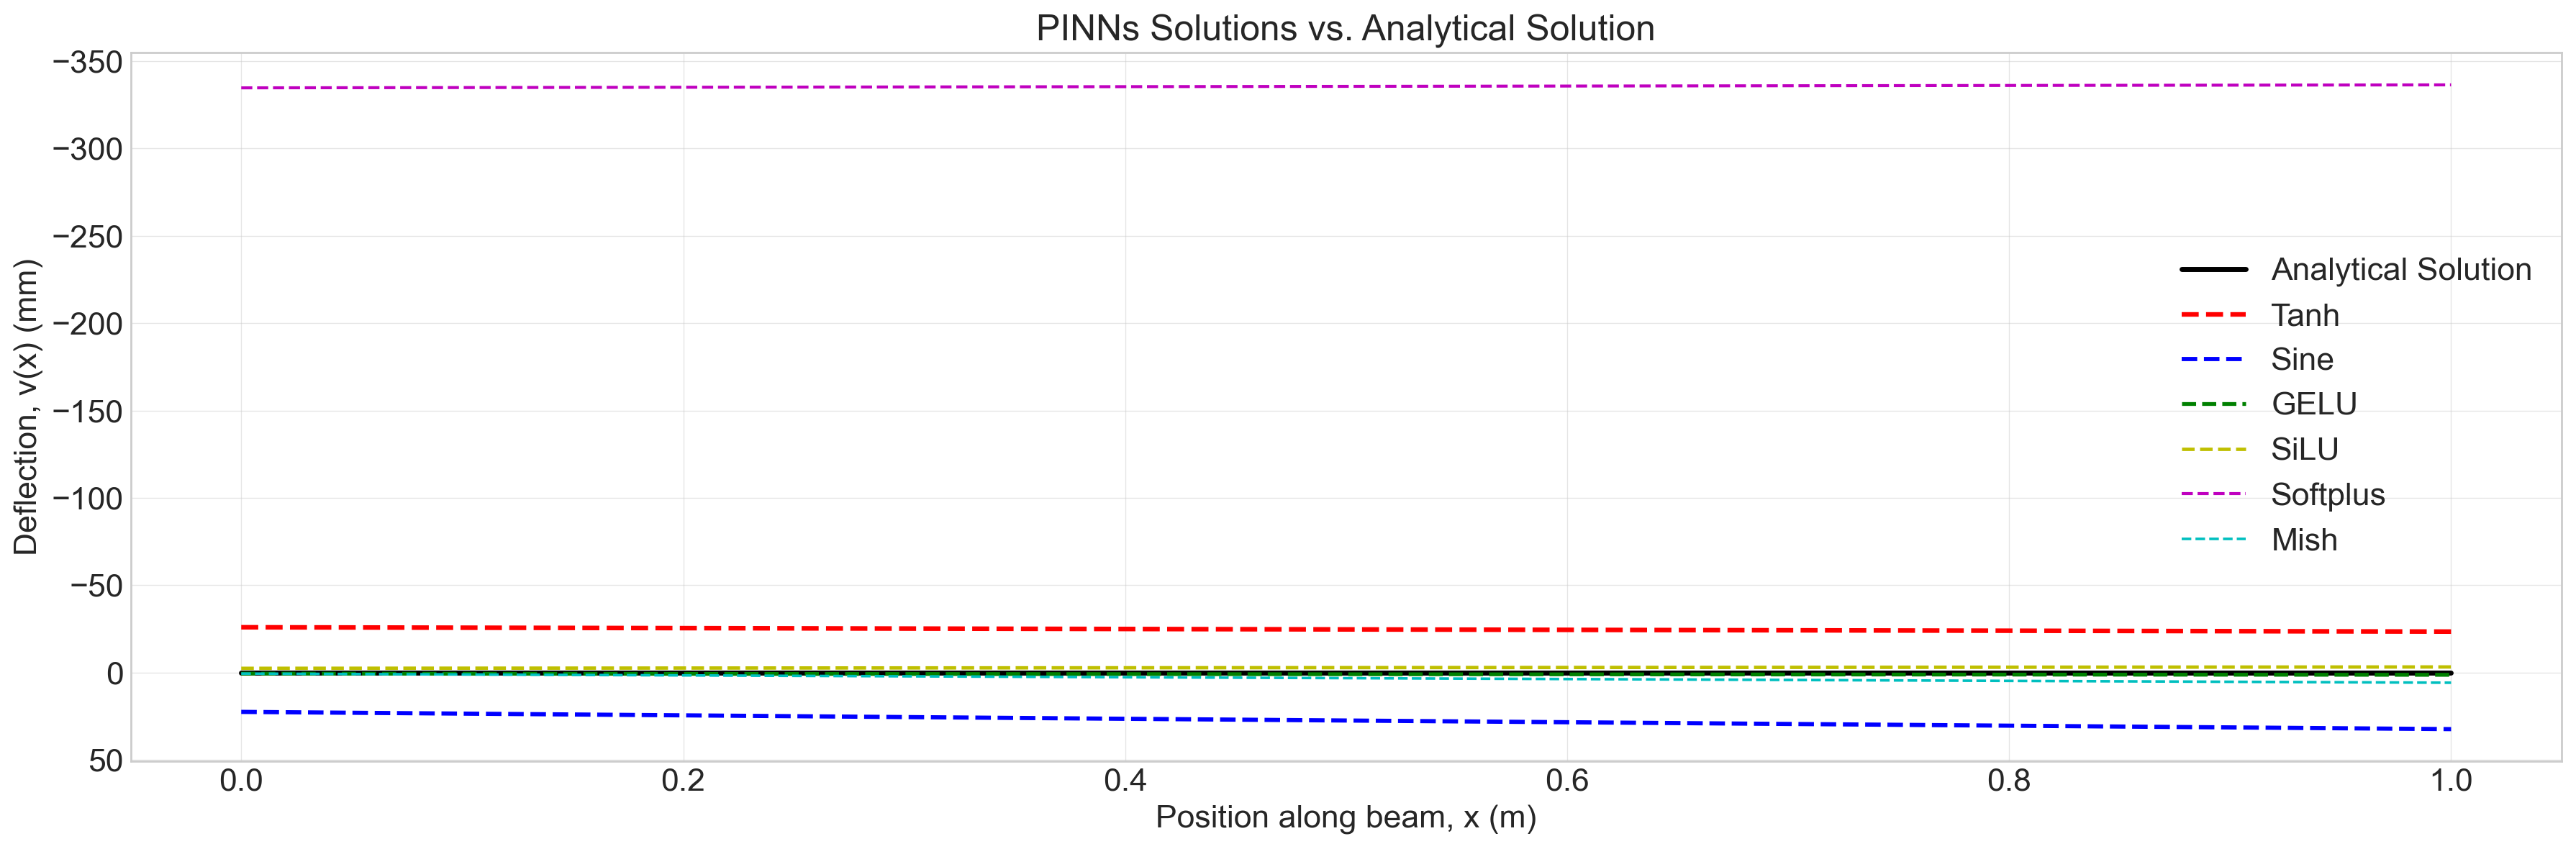

In [20]:
activations_names = ["Tanh", "Sine", "GELU", "SiLU", "Softplus", "Mish"]
plot_results(x_test, v_analytical, v_predictions, activations_names)

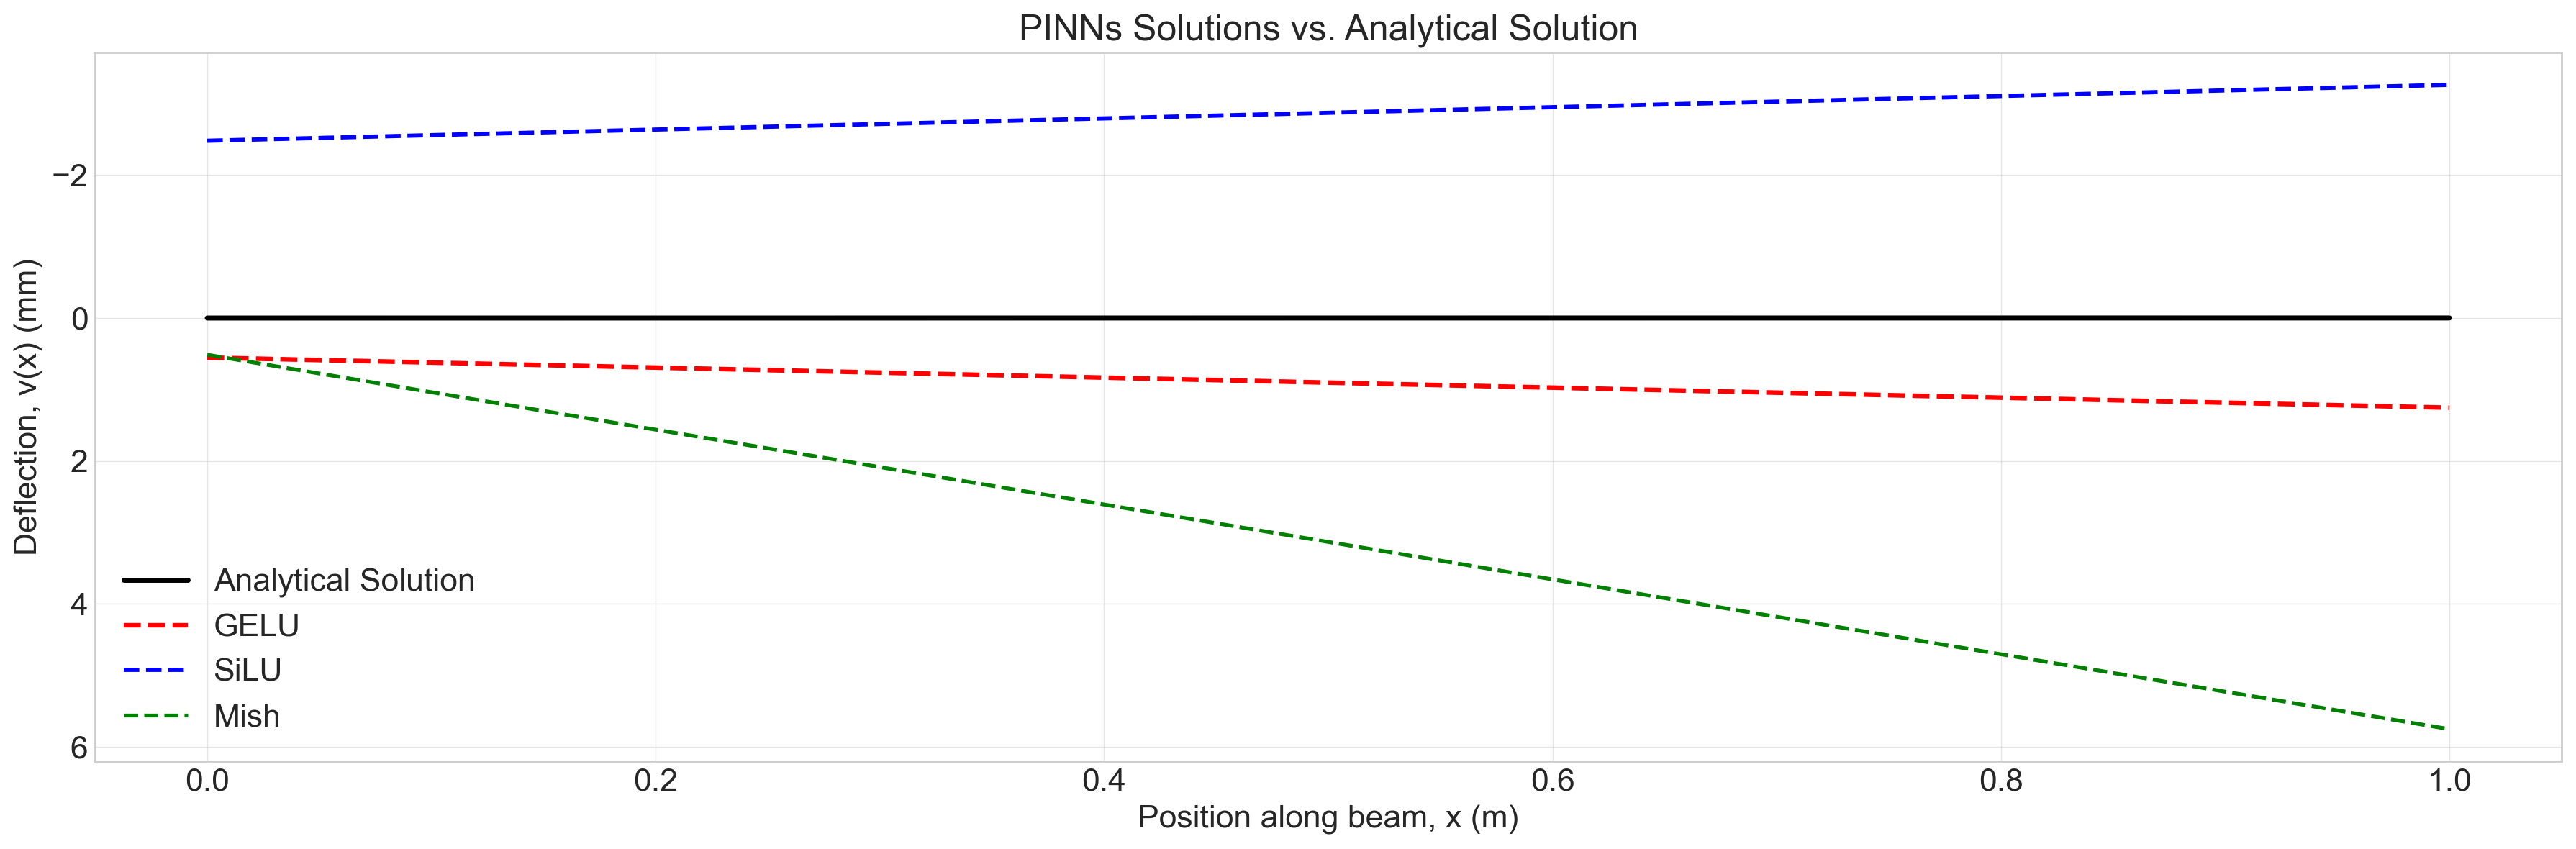

In [23]:
plot_results(x_test, v_analytical, [v_predictions[2], v_predictions[3], v_predictions[-1]], ["GELU", "SiLU", "Mish"])

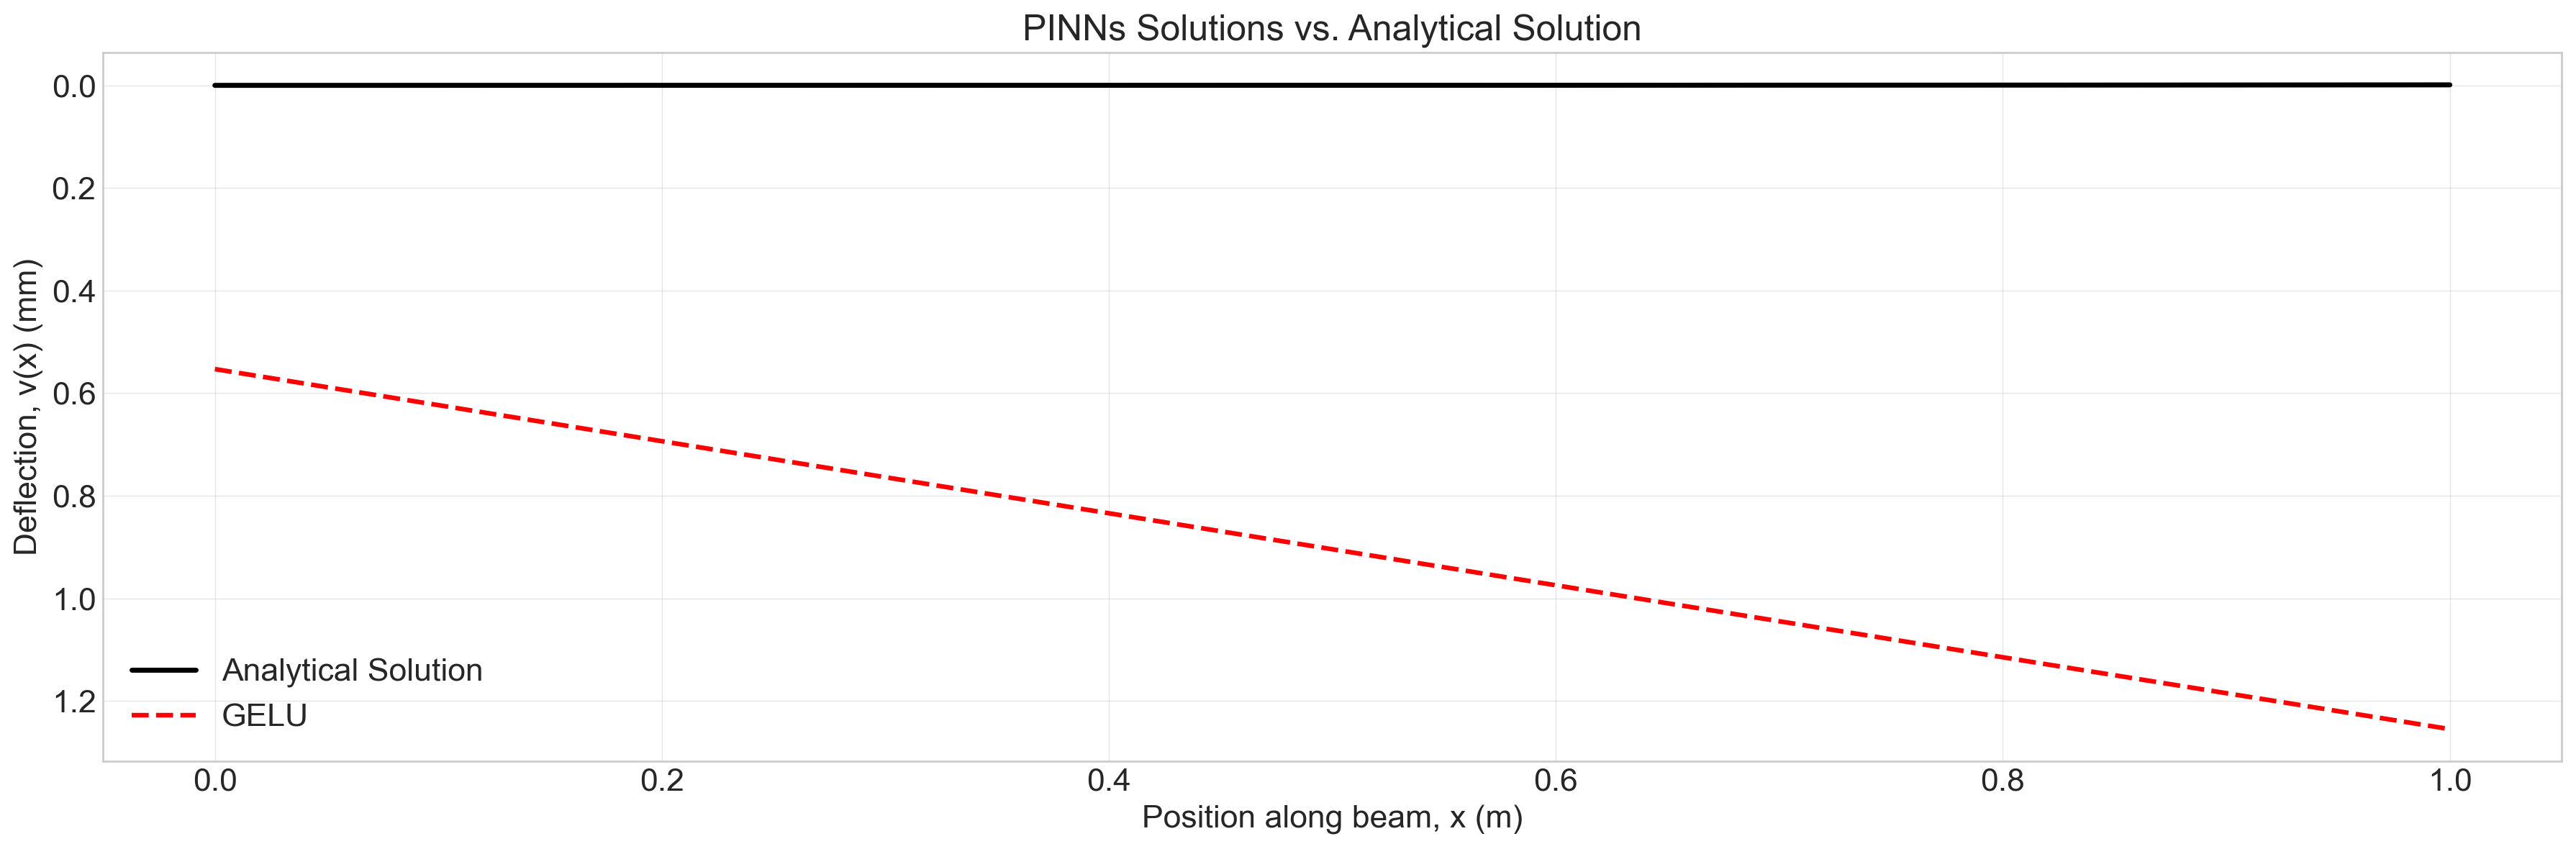

In [25]:
plot_results(x_test, v_analytical, [v_predictions[2]], ["GELU"])

In [ ]:
activation = F.gelu
v_pred = v_predictions[2]

## With gradient information (gPINN)

In [26]:
def train_gpinn(model, epochs, x_physics, batch_size,
                L, E, I, F0, M0, cf, q, lambda_bc, lambda_grad, device, checkpoint_path):
    loss_history, phys_loss_hist, bound_loss_hist, grad_loss_hist = [], [], [], []
    best_loss = float('inf')

    # --- Phase 1: Adam Optimizer (80% of epochs) ---
    adam_epochs = int(epochs * 0.8)
    print(f"--- Phase 1: Adam Optimizer for {adam_epochs} epochs ---")
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer_adam, gamma=0.9999)

    for epoch in range(adam_epochs):
        model.train()
        
        shuffled_indices = torch.randperm(x_physics.size(0))
        x_physics_shuffled = x_physics[shuffled_indices]

        epoch_total_loss, epoch_phys_loss, epoch_bound_loss, epoch_grad_loss = 0.0, 0.0, 0.0, 0.0
        n_batches = len(x_physics) // batch_size
        
        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            x_batch = x_physics_shuffled[start_idx:end_idx]

            optimizer_adam.zero_grad()
            loss_p = model.physics_loss(x_batch, E, I, cf, q)
            loss_grad_p = model.gradient_physics_loss(x_batch, E, I, cf, q)
            loss_b, _, _, _, _ = model.boundary_losses(L, E, I, F0, M0, device)
            
            total_loss = loss_p + lambda_bc * loss_b + lambda_grad * loss_grad_p
            
            total_loss.backward(retain_graph=True)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_adam.step()

            epoch_total_loss += total_loss.item()
            epoch_phys_loss += loss_p.item()
            epoch_bound_loss += loss_b.item()
            epoch_grad_loss += loss_grad_p.item()

        scheduler.step()
        
        avg_total_loss = epoch_total_loss / n_batches
        avg_phys_loss = epoch_phys_loss / n_batches
        avg_bound_loss = epoch_bound_loss / n_batches
        avg_grad_loss = epoch_grad_loss / n_batches
        if avg_total_loss < best_loss:
            best_loss = avg_total_loss
            save_checkpoint(model, checkpoint_path)
        
        loss_history.append(avg_total_loss)
        phys_loss_hist.append(avg_phys_loss)
        bound_loss_hist.append(avg_bound_loss)
        grad_loss_hist.append(avg_grad_loss)

        if (epoch + 1) % 1000 == 0:
            print(f'Epoch {epoch+1}/{adam_epochs} | Avg Loss: {avg_total_loss:.4e} | Best Loss: {best_loss:.4e} | '
                f'Phys Loss: {avg_phys_loss:.4e} | Bound Loss: {avg_bound_loss*lambda_bc:.4e} | Grad Loss: {avg_grad_loss*lambda_grad:.4e}')
        
    # --- Phase 2: L-BFGS Optimizer ---
    print(f"\n--- Phase 2: L-BFGS Optimizer for final convergence ---")
    load_checkpoint(model, checkpoint_path, device)
    model.train()

    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500, history_size=100)

    loss_containers = {'total': [0.0], 'phys': [0.0], 'bound': [0.0], 'grad': [0.0]}
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_p = model.physics_loss(x_physics, E, I, cf, q)
        loss_grad_p = model.gradient_physics_loss(x_physics, E, I, cf, q)
        loss_b, _, _, _, _ = model.boundary_losses(L, E, I, F0, M0, device)
        loss = loss_p + lambda_bc * loss_b + lambda_grad * loss_grad_p
        loss.backward()
        loss_containers['total'][0] = loss.item()
        loss_containers['phys'][0] = loss_p.item()
        loss_containers['bound'][0] = loss_b.item()
        loss_containers['grad'][0] = loss_grad_p.item()
        return loss

    optimizer_lbfgs.step(closure)
    
    print(f"Final L-BFGS Loss: {loss_containers['total'][0]:.4e}")
    loss_history.append(loss_containers['total'][0])
    phys_loss_hist.append(loss_containers['phys'][0])
    bound_loss_hist.append(loss_containers['bound'][0])
    grad_loss_hist.append(loss_containers['grad'][0])
    
    if loss_containers['total'][0] < best_loss:
        best_loss = loss_containers['total'][0]
        save_checkpoint(model, checkpoint_path)
    
    return loss_history, phys_loss_hist, bound_loss_hist, grad_loss_hist

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

lambda_grad = 0.01  # Weight for the gPINN term
checkpoint_filename = "best_gpinn_model.pth"
activation = torch.tanh  # Change for the best of the PINN run

gpinn = PINN(layers, activation).to(device)

x_physics = torch.rand(n_physics_points, 1, device=device) * L

loss_hist, phys_hist, bound_hist, grad_hist = train_gpinn(
    gpinn, epochs, x_physics, batch_size, 
    L, E, I, F0, M0, cf, q, lambda_bc, lambda_grad, device, checkpoint_filename
)

Using device: cuda
--- Phase 1: Adam Optimizer for 16000 epochs ---
Epoch 1000/16000 | Avg Loss: 5.9369e+04 | Best Loss: 5.9369e+04 | Phys Loss: 1.9536e+02 | Bound Loss: 5.9152e+04 | Grad Loss: 2.2277e+01
Epoch 2000/16000 | Avg Loss: 2.3066e+04 | Best Loss: 1.2780e+04 | Phys Loss: 3.3927e+01 | Bound Loss: 2.3032e+04 | Grad Loss: 5.8383e-01
Epoch 3000/16000 | Avg Loss: 6.1384e+03 | Best Loss: 3.3149e+03 | Phys Loss: 1.0455e+01 | Bound Loss: 6.1279e+03 | Grad Loss: 1.0542e-01
Epoch 4000/16000 | Avg Loss: 2.7157e+02 | Best Loss: 2.4900e+02 | Phys Loss: 4.7507e-01 | Bound Loss: 2.7105e+02 | Grad Loss: 4.7971e-02
Epoch 5000/16000 | Avg Loss: 1.4065e+02 | Best Loss: 1.4065e+02 | Phys Loss: 1.1785e-01 | Bound Loss: 1.4052e+02 | Grad Loss: 1.1322e-02
Epoch 6000/16000 | Avg Loss: 8.8235e+01 | Best Loss: 8.5024e+01 | Phys Loss: 4.1438e-02 | Bound Loss: 8.8192e+01 | Grad Loss: 1.6664e-03
Epoch 7000/16000 | Avg Loss: 5.5790e+01 | Best Loss: 5.3454e+01 | Phys Loss: 2.4700e-02 | Bound Loss: 5.5764e+

In [28]:
load_checkpoint(gpinn, checkpoint_filename, device)
gpinn.eval()
with torch.no_grad():
    v_pred_gpinn = gpinn(x_test)

Loading best model from best_gpinn_model.pth...


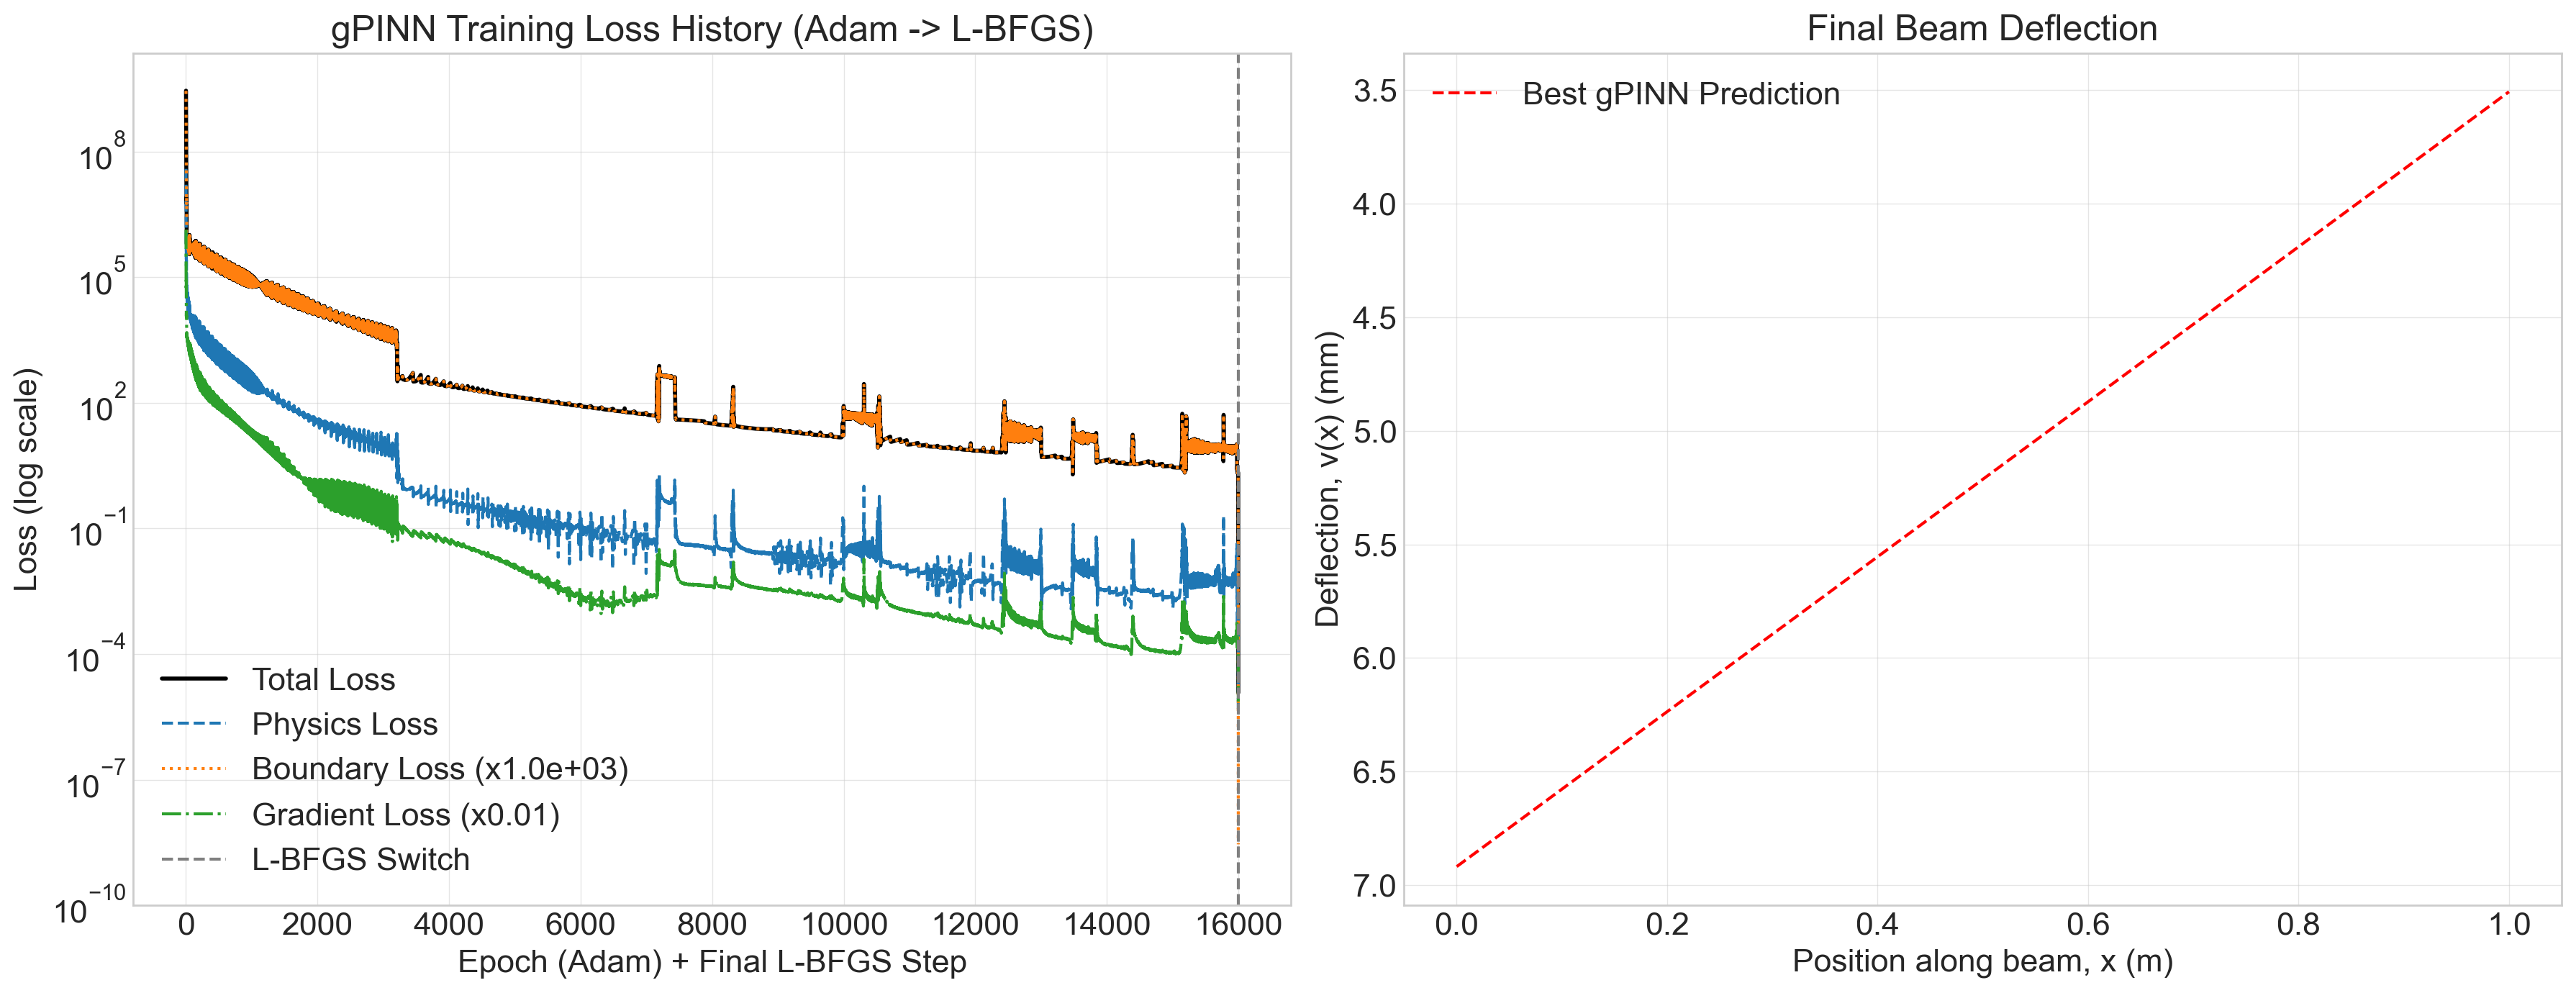

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
# Plot loss components
ax1.semilogy(loss_hist, label='Total Loss', color='black', linewidth=2)
ax1.semilogy(phys_hist, label='Physics Loss', linestyle='--')
ax1.semilogy(np.array(bound_hist) * lambda_bc, label=f'Boundary Loss (x{lambda_bc:.1e})', linestyle=':')
ax1.semilogy(np.array(grad_hist) * lambda_grad, label=f'Gradient Loss (x{lambda_grad})', linestyle='-.')
ax1.set_title('gPINN Training Loss History (Adam -> L-BFGS)')
ax1.set_xlabel('Epoch (Adam) + Final L-BFGS Step')
ax1.set_ylabel('Loss (log scale)')
ax1.axvline(x=int(epochs*0.8), color='grey', linestyle='--', label='L-BFGS Switch')
ax1.legend()
ax1.grid(True)
ax1.set_ylim(bottom=1e-10) # Set a floor for the y-axis

# Plot final solution
x_test = torch.linspace(0, L, 500, device=device).view(-1, 1)
with torch.no_grad():
    v_pred = gpinn(x_test)

ax2.plot(x_test.cpu().numpy(), v_pred.cpu().numpy() * 1000, 'r--', label='Best gPINN Prediction')
ax2.set_title('Final Beam Deflection')
ax2.set_xlabel('Position along beam, x (m)')
ax2.set_ylabel('Deflection, v(x) (mm)')
ax2.legend()
ax2.invert_yaxis()
ax2.grid(True)

plt.tight_layout()
plt.show()

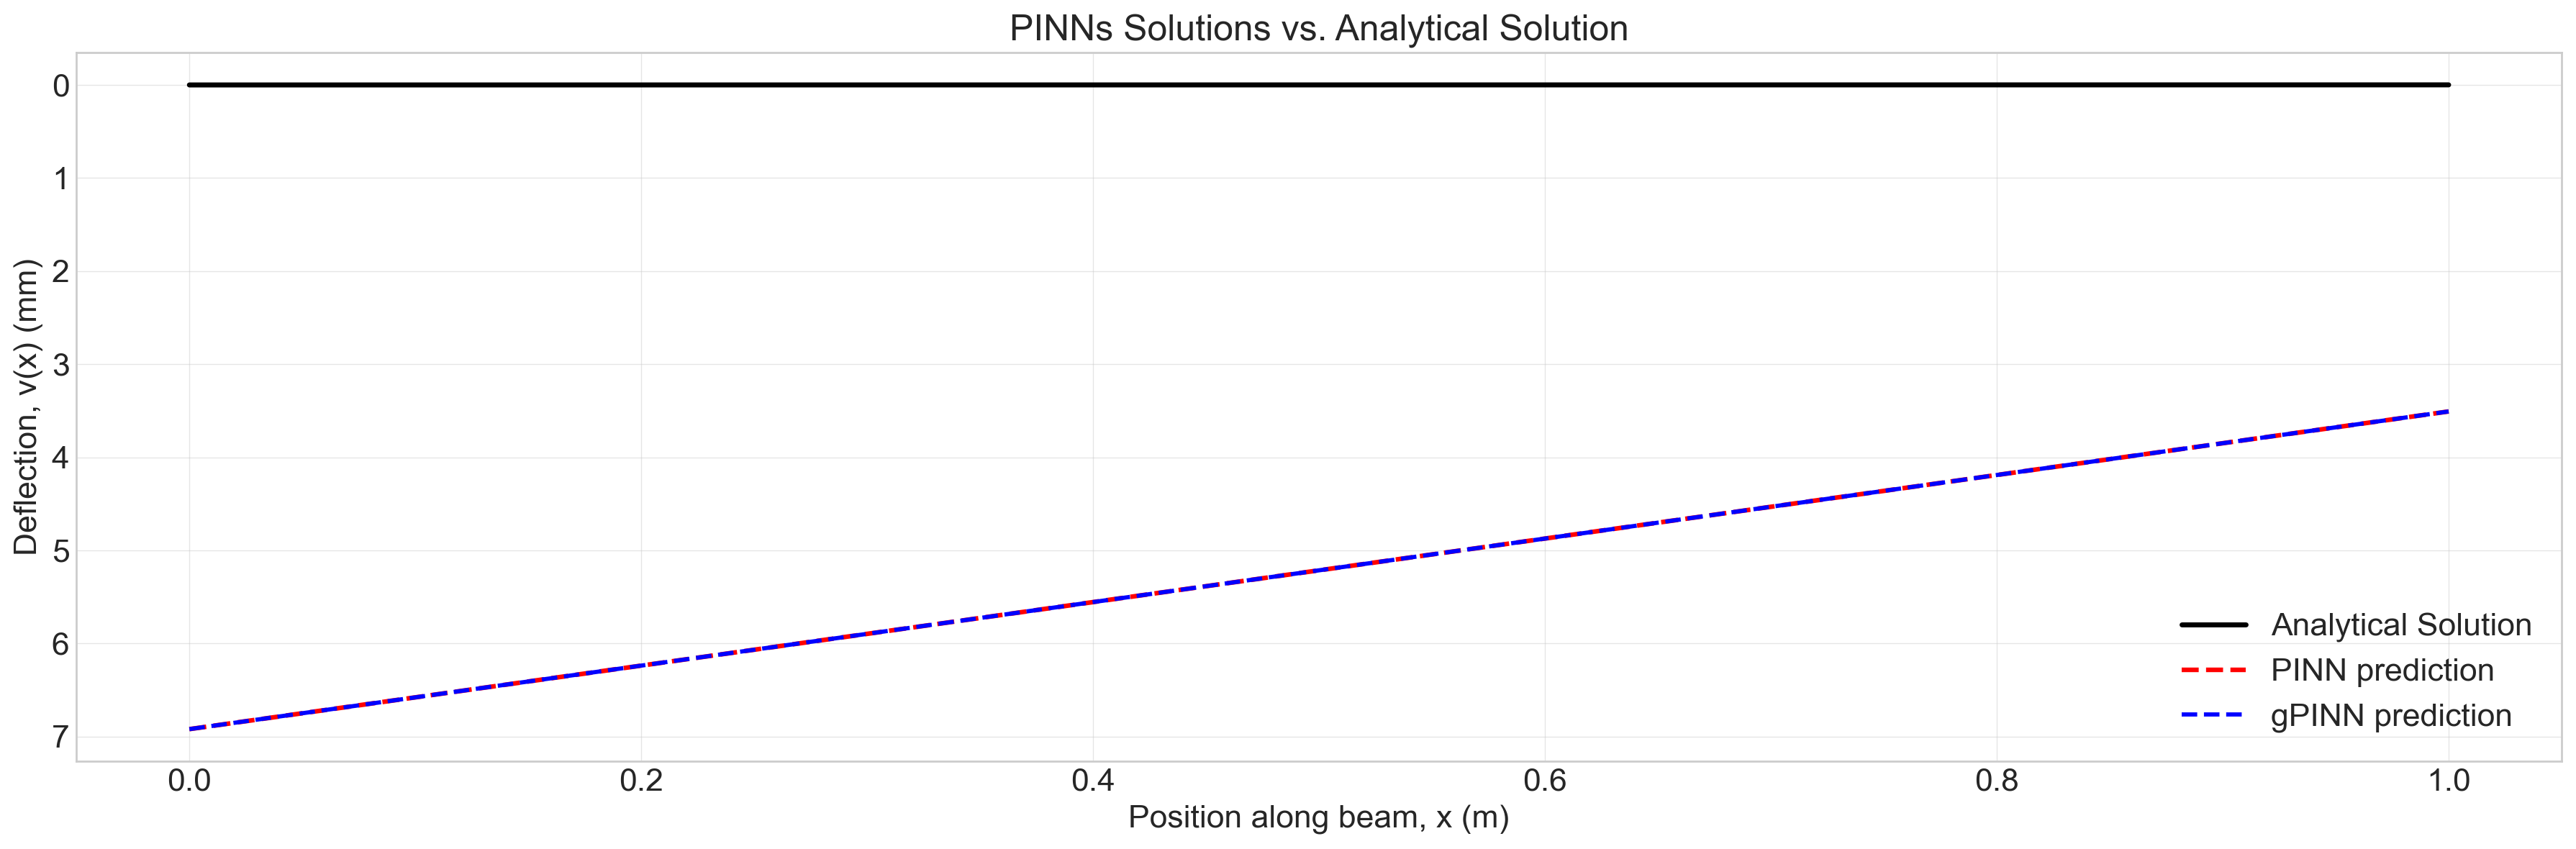

In [30]:
plot_results(x_test, v_analytical, [v_pred, v_pred_gpinn], ["PINN prediction", "gPINN prediction"])

Both the PINN (with GELU) and the gPINN (with Tanh) performed pretty much the same. The difficulty is probably in the boundary conditions.

It seems difficult to fulfill the boundary conditions, because we have high values of $E$ and $I$, and the third and fourth boundary conditions, the ones in $L$, end up having high values because of the $E \times I$ multiplication.

It is a hard problem to learn and it requires advanced strategies such as Adaptive Weights and Residual-Based Adaptive Refinement.

## Adaptive weights

In [31]:
class PINN(nn.Module):
    """
    Base Physics-Informed Neural Network class.
    """
    def __init__(self, layers, activation=torch.tanh):
        super(PINN, self).__init__()
        self.activation = activation
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.init_weights()

    def init_weights(self):
        for m in self.linears:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        if x.dim() == 1:
            x = x.view(-1, 1)
        for i, layer in enumerate(self.linears[:-1]):
            x = self.activation(layer(x))
        x = self.linears[-1](x)
        return x

    def compute_residual(self, x, E, I, cf, q):
        x.requires_grad_(True)
        v = self.forward(x)
        v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
        v_xxx = torch.autograd.grad(v_xx, x, torch.ones_like(v_xx), create_graph=True)[0]
        v_xxxx = torch.autograd.grad(v_xxx, x, torch.ones_like(v_xxx), create_graph=True)[0]
        return (E * I * v_xxxx + cf * v - q)/(E*I)

    def boundary_loss_calc(self, L, E, I, F0, M0, device='cpu'):
        x_0 = torch.tensor([[0.0]], requires_grad=True, device=device)
        x_L = torch.tensor([[L]], requires_grad=True, device=device)
        v_0 = self.forward(x_0)
        v_L = self.forward(x_L)
        v_x_0 = torch.autograd.grad(v_0, x_0, torch.ones_like(v_0), create_graph=True)[0]
        v_x_L = torch.autograd.grad(v_L, x_L, grad_outputs=torch.ones_like(v_L), create_graph=True)[0]
        v_xx_L = torch.autograd.grad(v_x_L, x_L, grad_outputs=torch.ones_like(v_x_L), create_graph=True)[0]
        v_xxx_L = torch.autograd.grad(v_xx_L, x_L, grad_outputs=torch.ones_like(v_xx_L), create_graph=True)[0]
        loss_bc1 = torch.mean(v_0**2)
        loss_bc2 = torch.mean(v_x_0**2)
        loss_bc3 = torch.mean((E * I * v_xx_L + M0)**2)
        loss_bc4 = torch.mean((E * I * v_xxx_L + F0)**2)
        return (loss_bc1 + loss_bc2 + loss_bc3 + loss_bc4)/(E*I)

# --- PINN with Learnable Weights ---
class LearnableWeightPINN(PINN):
    def __init__(self, layers, activation=torch.tanh):
        super().__init__(layers, activation)
        self.lambda_physics = nn.Parameter(torch.tensor(1.0))
        self.lambda_boundary = nn.Parameter(torch.tensor(1.0))

    def loss_function(self, x_physics, L, E, I, F0, M0, cf, q, device):
        loss_physics_raw = torch.mean(self.compute_residual(x_physics, E, I, cf, q)**2)
        loss_boundary_raw = self.boundary_loss_calc(L, E, I, F0, M0, device)
        total_loss = torch.abs(self.lambda_physics) * loss_physics_raw + \
                     torch.abs(self.lambda_boundary) * loss_boundary_raw
        return total_loss, loss_physics_raw, loss_boundary_raw

In [32]:
def train_learnable_weights(model, epochs, x_physics, batch_size, lr, device, checkpoint_path):
    loss_history, lambda_history, phys_loss_hist, bound_loss_hist = [], [], [], []
    best_loss = float('inf')
    
    adam_epochs = int(epochs * 0.8)
    print(f"--- Phase 1: Adam Optimizer for {adam_epochs} epochs ---")
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer_adam, gamma=0.9999)

    for epoch in range(adam_epochs):
        model.train()
        
        # Shuffle data for mini-batching
        shuffled_indices = torch.randperm(x_physics.size(0))
        x_physics_shuffled = x_physics[shuffled_indices]
        
        epoch_total_loss, epoch_phys_loss, epoch_bound_loss = 0.0, 0.0, 0.0
        n_batches = len(x_physics) // batch_size
        if n_batches == 0:
            raise ValueError("batch_size is larger than the number of collocation points.")

        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            x_batch = x_physics_shuffled[start_idx:end_idx]

            optimizer_adam.zero_grad()
            
            loss, loss_p, loss_b = model.loss_function(x_batch, L, E, I, F0, M0, cf, q, device)
            
            loss.backward(retain_graph=True)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer_adam.step()

            epoch_total_loss += loss.item()
            epoch_phys_loss += loss_p.item()
            epoch_bound_loss += loss_b.item()

        scheduler.step()

        avg_epoch_loss = epoch_total_loss / n_batches
        avg_phys_loss = epoch_phys_loss / n_batches
        avg_bound_loss = epoch_bound_loss / n_batches
        loss_history.append(avg_epoch_loss)
        phys_loss_hist.append(epoch_phys_loss / n_batches)
        bound_loss_hist.append(epoch_bound_loss / n_batches)
        lambda_history.append([model.lambda_physics.item(), model.lambda_boundary.item()])

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            save_checkpoint(model, checkpoint_path)

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1:5d} | Avg Loss: {avg_epoch_loss:.4e} | Best Loss: {best_loss:.4e} | "
                  f"Phys Loss: {avg_phys_loss*model.lambda_physics.item():.4e} | Bound Loss: {avg_bound_loss*model.lambda_boundary.item():.4e} | "
                  f"λ_phys: {model.lambda_physics.item():.3f} | "
                  f"λ_bound: {model.lambda_boundary.item():.3f}")

    # --- Phase 2: L-BFGS Optimizer ---
    load_checkpoint(model, checkpoint_path, device)
    model.train()
    
    print(f"\n--- Phase 2: L-BFGS Optimizer for final convergence ---")
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500)

    loss_containers = {'total': [0.0], 'phys': [0.0], 'bound': [0.0]}
    def closure():
        optimizer_lbfgs.zero_grad()
        loss, loss_p, loss_b = model.loss_function(x_physics, L, E, I, F0, M0, cf, q, device)
        loss.backward(retain_graph=True)
        loss_containers['total'][0] = loss.item()
        loss_containers['phys'][0] = loss_p.item()
        loss_containers['bound'][0] = loss_b.item()
        return loss

    optimizer_lbfgs.step(closure)
    
    if loss_containers['total'][0] < best_loss:
        best_loss = loss_containers['total'][0]
        save_checkpoint(model, checkpoint_path)
    
    loss, loss_p, loss_b = model.loss_function(x_physics, L, E, I, F0, M0, cf, q, device)
    print(f"Final L-BFGS Loss: {loss_containers['total'][0]:.4e}")
    loss_history.append(loss_containers['total'][0])
    phys_loss_hist.append(loss_containers['phys'][0])
    bound_loss_hist.append(loss_containers['bound'][0])

    return loss_history, lambda_history, phys_loss_hist, bound_loss_hist

In [ ]:
checkpoint_filename = "best_learnable_weights_model.pth"
labels = []

wPINN = LearnableWeightPINN(layers).to(device)
x_physics = torch.rand(n_physics_points, 1, device=device) * L

loss_hist, lambda_hist, phys_hist, bound_hist = train_learnable_weights(
        wPINN, epochs, x_physics, batch_size, learning_rate, device, checkpoint_filename
    )
# --- Load the best model for final visualization ---
load_checkpoint(wPINN, checkpoint_filename, device)
wPINN.eval()

lambda_hist = np.array(lambda_hist)
phys_hist = np.array(phys_hist)
bound_hist = np.array(bound_hist)

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
C:\Users\gabri\AppData\Local\Temp\ipykernel_20924\2095713583.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(lambda_hist[:, 0], label='$\lambda_{physics}$')
C:\Users\gabri\AppData\Local\Temp\ipykernel_20924\2095713583.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(lambda_hist[:, 1], label='$\lambda_{boundary}$')


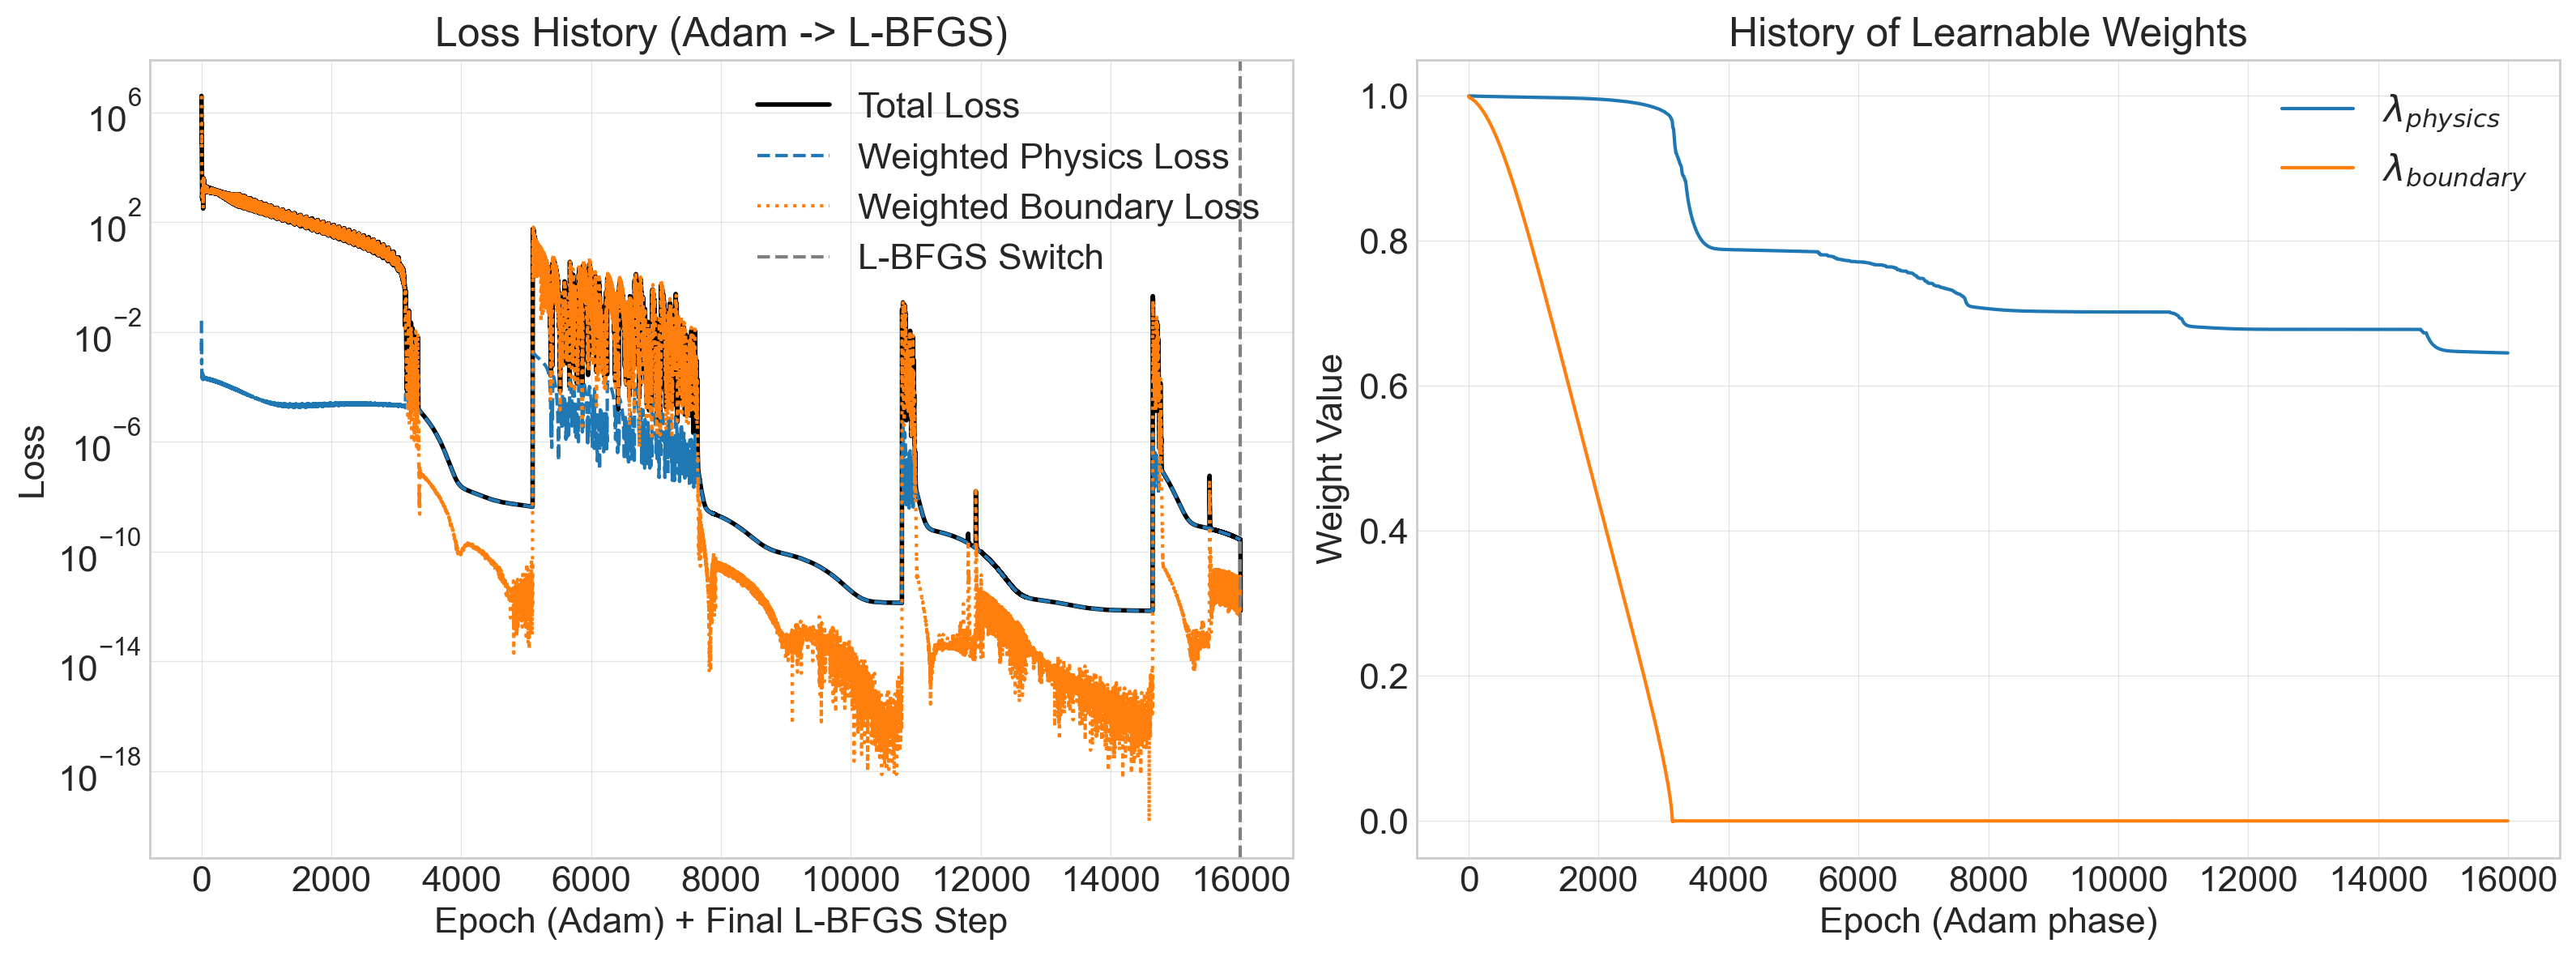

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot weighted loss components
ax1.semilogy(loss_hist, label='Total Loss', color='black', linewidth=2)
ax1.semilogy(np.abs(lambda_hist[:, 0]) * phys_hist[:-1], label='Weighted Physics Loss', linestyle='--')
ax1.semilogy(np.abs(lambda_hist[:, 1]) * bound_hist[:-1], label='Weighted Boundary Loss', linestyle=':')
ax1.set_title("Loss History (Adam -> L-BFGS)")
ax1.set_xlabel("Epoch (Adam) + Final L-BFGS Step")
ax1.set_ylabel("Loss")
ax1.axvline(x=int(epochs*0.8), color='grey', linestyle='--', label='L-BFGS Switch')
ax1.legend()
ax1.grid(True)

# Plot learnable weights
ax2.plot(lambda_hist[:, 0], label='$\lambda_{physics}$')
ax2.plot(lambda_hist[:, 1], label='$\lambda_{boundary}$')
ax2.set_title("History of Learnable Weights")
ax2.set_xlabel("Epoch (Adam phase)")
ax2.set_ylabel("Weight Value")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

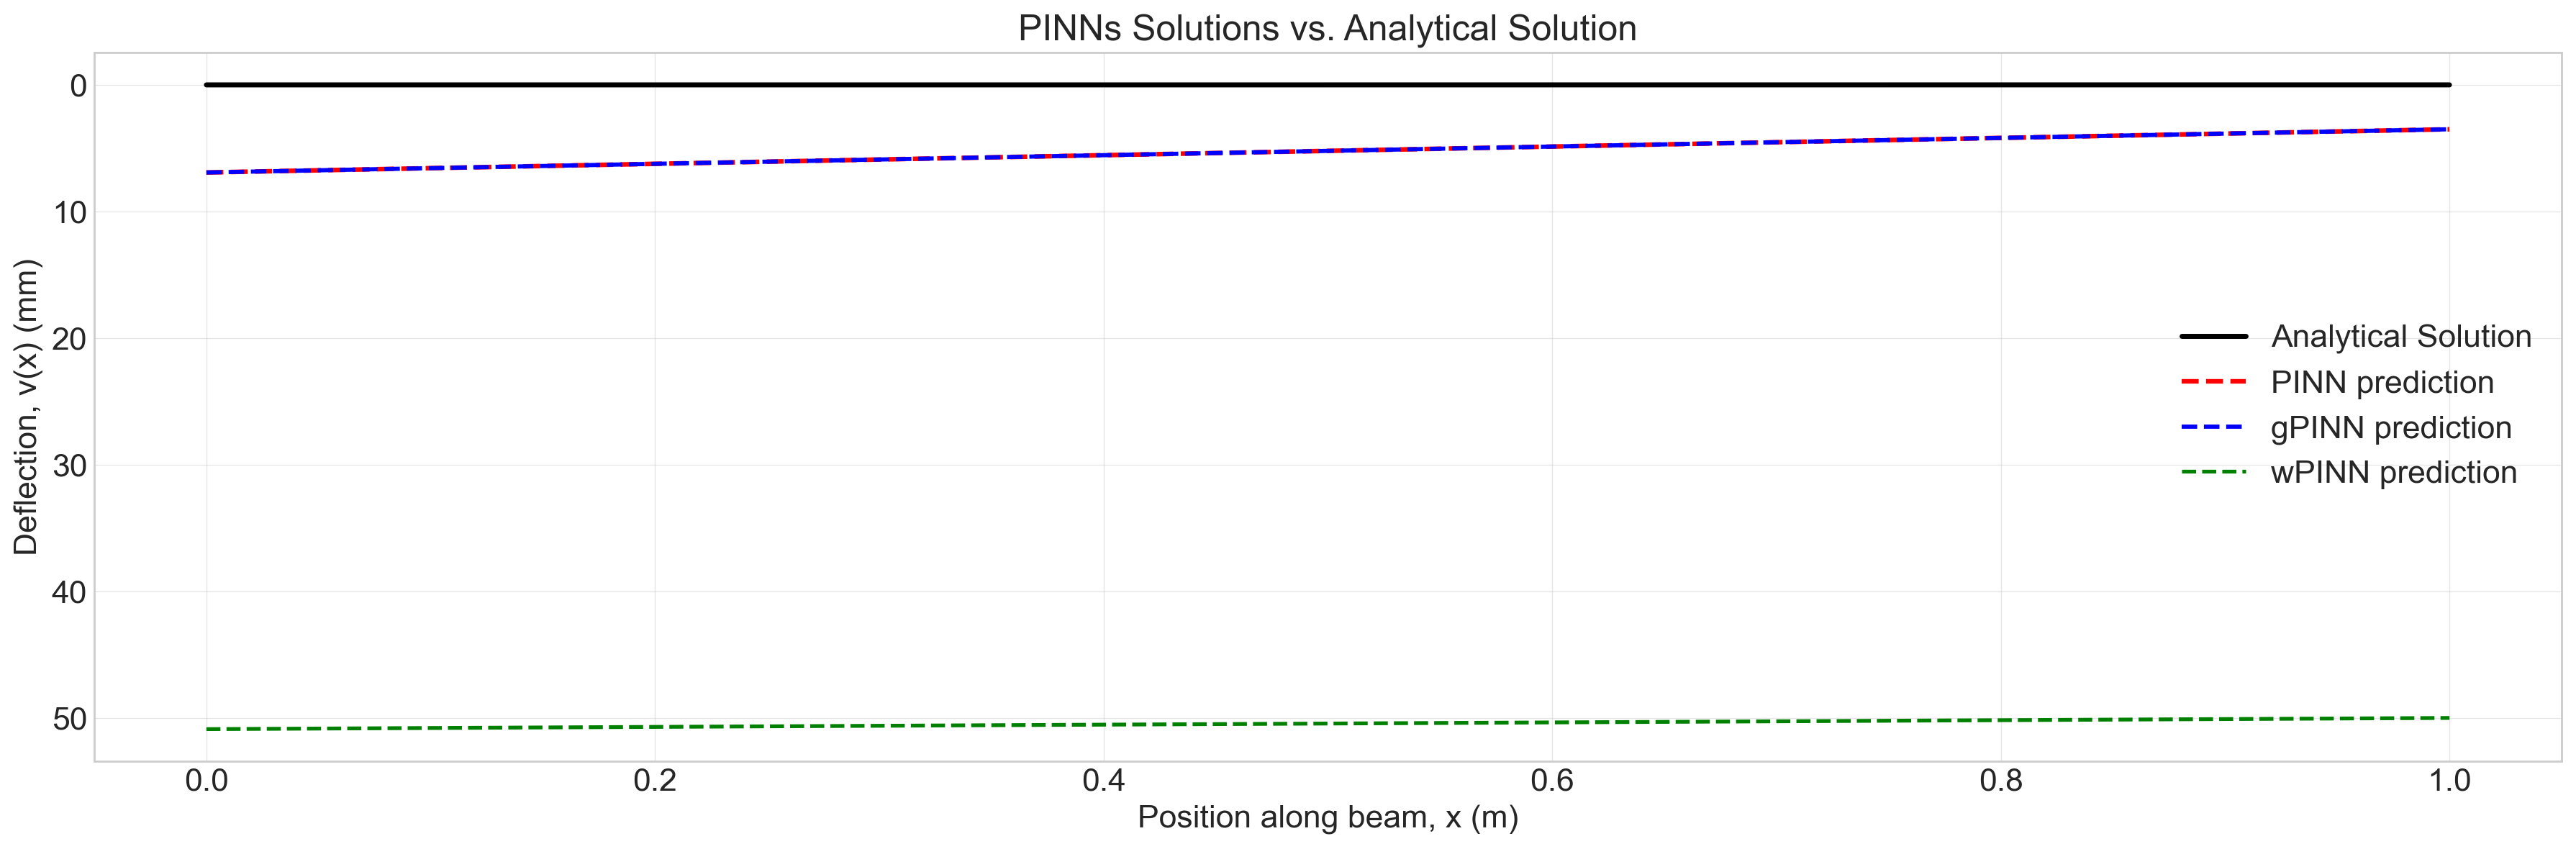

In [45]:
with torch.no_grad():
    v_pred_wPINN = wPINN(x_test)

plot_results(x_test, v_analytical, [v_pred, v_pred_gpinn, v_pred_wPINN], ["PINN prediction", "gPINN prediction", "wPINN prediction"])

## Residual-based Adaptive Refinement

In [46]:
class AdaptiveRefinementPINN(PINN):
    def __init__(self, layers, activation=torch.tanh):
        super().__init__(layers, activation)
    
    def adaptive_sampling(self, x_physics, E, I, cf, q, percentile=0.1, max_points=10000, noise_factor=0.05):
        """Add more training points where the absolute PDE residual is high."""
        self.eval() # Set to evaluation mode for sampling
        
        # This part requires gradients to be enabled
        residuals = self.compute_residual(x_physics, E, I, cf, q).abs()
        
        # The rest can be done without tracking gradients
        with torch.no_grad():
            # Determine the residual threshold based on the top percentile
            refinement_threshold = torch.quantile(residuals, 1.0 - percentile)
            high_residual_mask = (residuals >= refinement_threshold).squeeze()
            
            n_current = len(x_physics)
            n_to_add = high_residual_mask.sum().item()

            if n_to_add > 0 and n_current < max_points:
                high_residual_points = x_physics[high_residual_mask]
                
                n_new = min(1000, max_points - n_current)
                if n_new > 0 and len(high_residual_points) > 0:
                    # Create new points by adding noise to the high-residual points
                    noise = (L * noise_factor) * torch.randn(n_new, 1, device=x_physics.device)
                    sample_indices = torch.randint(0, len(high_residual_points), (n_new,))
                    new_points = high_residual_points[sample_indices] + noise
                    new_points = torch.clamp(new_points, 0, L)
                    
                    x_physics = torch.cat([x_physics, new_points], dim=0)
                    print(f"  [RAR] Added {n_new} new points. Total points: {len(x_physics)}")
        return x_physics

In [47]:
def train_rar(model, epochs, x_physics, batch_size, lr, device, checkpoint_path,
              lambda_bc, adapt_every=500):
    loss_history, phys_loss_hist, bound_loss_hist = [], [], []
    best_loss = float('inf')
    
    adam_epochs = int(epochs * 0.8)
    print(f"--- Phase 1: Adam Optimizer for {adam_epochs} epochs ---")
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer_adam, gamma=0.9999)

    for epoch in range(adam_epochs):
        model.train()
        
        if epoch % adapt_every == 0:
            print(f"Epoch {epoch} - Performing adaptive refinement...")
            x_physics = model.adaptive_sampling(x_physics, E, I, cf, q)
            x_physics.requires_grad = True

        shuffled_indices = torch.randperm(x_physics.size(0))
        x_physics_shuffled = x_physics[shuffled_indices]
        
        epoch_total_loss, epoch_phys_loss, epoch_bound_loss = 0.0, 0.0, 0.0
        n_batches = len(x_physics) // batch_size
        if n_batches == 0: raise ValueError("batch_size > n_physics_points")

        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            x_batch = x_physics_shuffled[start_idx:end_idx]

            optimizer_adam.zero_grad()
            
            loss_p = torch.mean(model.compute_residual(x_batch, E, I, cf, q)**2)
            loss_b = model.boundary_loss_calc(L, E, I, F0, M0, device)
            total_loss = loss_p + lambda_bc * loss_b
            
            total_loss.backward(retain_graph=True)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer_adam.step()
            
            epoch_total_loss += total_loss.item()
            epoch_phys_loss += loss_p.item()
            epoch_bound_loss += loss_b.item()

        scheduler.step()

        avg_epoch_loss = epoch_total_loss / n_batches
        avg_phys_loss = epoch_phys_loss / n_batches
        avg_bound_loss = epoch_bound_loss / n_batches
        loss_history.append(avg_epoch_loss)
        phys_loss_hist.append(avg_phys_loss)
        bound_loss_hist.append(avg_bound_loss)

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            save_checkpoint(model, checkpoint_path)

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1:5d} | Avg Loss: {avg_epoch_loss:.4e} | Best Loss: {best_loss:.4e} | "
                  f"Phys Loss: {avg_phys_loss:.4e} | Bound Loss: {avg_bound_loss*lambda_bc:.4e}")

    # --- Phase 2: L-BFGS Optimizer ---
    load_checkpoint(model, checkpoint_path, device)
    model.train()
    
    print(f"\n--- Phase 2: L-BFGS Optimizer for final convergence ---")
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500)
    loss_containers = {'total': [0.0], 'phys': [0.0], 'bound': [0.0]}
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_p = torch.mean(model.compute_residual(x_physics, E, I, cf, q)**2)
        loss_b = model.boundary_loss_calc(L, E, I, F0, M0, device)
        loss = loss_p + lambda_bc * loss_b
        loss.backward(retain_graph=True)
        loss_containers['total'][0] = loss.item()
        loss_containers['phys'][0] = loss_p.item()
        loss_containers['bound'][0] = loss_b.item()
        return loss

    optimizer_lbfgs.step(closure)
    
    final_loss = loss_containers['total'][0]
    print(f"Final L-BFGS Loss: {final_loss:.4e}")
    loss_history.append(final_loss)
    phys_loss_hist.append(loss_containers['phys'][0])
    bound_loss_hist.append(loss_containers['bound'][0])
    
    if final_loss < best_loss:
        best_loss = final_loss
        save_checkpoint(model, checkpoint_path)

    return loss_history, phys_loss_hist, bound_loss_hist

In [48]:
checkpoint_filename = "best_rar_model.pth"
n_initial_points = 1000

In [49]:
rPINN = AdaptiveRefinementPINN(layers).to(device)
x_physics = L * torch.rand(n_initial_points, 1, device=device)

loss_hist, phys_hist, bound_hist = train_rar(
    rPINN, epochs, x_physics, batch_size, learning_rate, device, checkpoint_filename, lambda_bc
)

--- Phase 1: Adam Optimizer for 16000 epochs ---
Epoch 0 - Performing adaptive refinement...
  [RAR] Added 1000 new points. Total points: 2000
Epoch 500 - Performing adaptive refinement...
  [RAR] Added 1000 new points. Total points: 3000
Epoch  1000 | Avg Loss: 2.2995e+05 | Best Loss: 2.2138e+05 | Phys Loss: 2.0113e-05 | Bound Loss: 2.2995e+05
Epoch 1000 - Performing adaptive refinement...
  [RAR] Added 1000 new points. Total points: 4000
Epoch 1500 - Performing adaptive refinement...
  [RAR] Added 1000 new points. Total points: 5000
Epoch  2000 | Avg Loss: 1.5117e+04 | Best Loss: 1.1767e+04 | Phys Loss: 1.9357e-08 | Bound Loss: 1.5117e+04
Epoch 2000 - Performing adaptive refinement...
  [RAR] Added 1000 new points. Total points: 6000
Epoch 2500 - Performing adaptive refinement...
  [RAR] Added 1000 new points. Total points: 7000
Epoch  3000 | Avg Loss: 2.8781e+02 | Best Loss: 2.8272e+02 | Phys Loss: 1.5925e-07 | Bound Loss: 2.8781e+02
Epoch 3000 - Performing adaptive refinement...
  

KeyboardInterrupt: 

In [ ]:
fig, (ax1) = plt.subplots(1, 1, figsize=(10, 7))

ax1.semilogy(loss_hist, label='Total Loss', color='black', linewidth=2)
ax1.semilogy(phys_hist, label='Physics Loss', linestyle='--')
ax1.semilogy(np.array(bound_hist) * lambda_bc, label=f'Boundary Loss (x{lambda_bc:.1e})', linestyle=':')
ax1.set_title("RAR PINN Loss History (Adam -> L-BFGS)")
ax1.set_xlabel("Epoch (Adam) + Final L-BFGS Step")
ax1.set_ylabel("Loss (log scale)")
ax1.axvline(x=int(epochs*0.8), color='grey', linestyle='--', label='L-BFGS Switch')
ax1.legend()
ax1.grid(True)
ax1.set_ylim(bottom=1e-5) # Set a floor for y-axis

plt.tight_layout()
plt.show()


In [ ]:
load_checkpoint(rPINN, checkpoint_filename, device)
rPINN.eval()

with torch.no_grad():
    v_pred_rPINN = rPINN(x_test)

plot_results(x_test, v_analytical, [v_pred, v_pred_gpinn, v_pred_wPINN, v_pred_rPINN], ["PINN prediction", "Grad PINN", "Adaptive Weights PINN", "Adaptive Refinement PINN"])

# References:
[1] Seman, Laio Oriel. Material de aula sobre PINNs. 2025.

[2] Lopez, Rafael Holdorf. Notas de aula Cálculo Variacional. Elsevier, 2020.